# Late Shipment Risk Classification

We predict whether an order will be shipped after its required date.

The prediction is made using information available when the order is created.

The notebook follows six steps:

1. Load and prepare order data.
2. Explore late shipment patterns.
3. Create features available before shipment.
4. Compare classification models.
5. Evaluate the selected model on later orders.
6. Save the final model and predictions.

The target is **late shipment risk**.

A late shipment is defined as:

**Shipped Date > Required Date**

Post-shipment information will not be used as model input.

In [162]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (
    PROJECT_ROOT
    / "src"
    / "database.py"
).exists():
    raise FileNotFoundError(
        "Please run from the project folder or notebooks folder."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )

from src.database import create_db_engine

PROJECT_ROOT

WindowsPath('c:/Users/okand/Desktop/Projects/Bikestores Analytics')

In [5]:
START_DATE = "2016-01-01"
END_DATE_EXCLUSIVE = "2018-04-01"

## 1. Load and Prepare the Data

We first inspect the available order data before defining the target and model features.

The prediction dataset will use one row per order.

Only information available before shipment will be considered for model features.

In [3]:
engine = create_db_engine()

query = """
SHOW COLUMNS
FROM vw_excel_orders;
"""

order_columns = pd.read_sql_query(
    query,
    engine
)

engine.dispose()

order_columns

,Field,Type,Null,Key,Default,Extra
0,order_id,int,NO,,0,
1,order_date,date,NO,,NaN,
2,report_year,int,YES,,NaN,
3,report_quarter,int,YES,,NaN,
4,month_number,int,YES,,NaN,
5,month_name,varchar(9),YES,,NaN,
6,year_monthh,varchar(7),YES,,NaN,
7,month_start,date,YES,,NaN,
8,is_reliable_period,int,NO,,0,
9,reporting_period_status,varchar(26),NO,,,


In [4]:
engine = create_db_engine()

query = """
SHOW COLUMNS
FROM vw_excel_order_items;
"""

order_item_columns = pd.read_sql_query(
    query,
    engine
)

engine.dispose()

order_item_columns

,Field,Type,Null,Key,Default,Extra
0,order_id,int,NO,,0,
1,item_id,int,NO,,NaN,
2,order_date,date,NO,,NaN,
3,report_year,int,YES,,NaN,
4,report_quarter,int,YES,,NaN,
5,month_number,int,YES,,NaN,
6,month_name,varchar(9),YES,,NaN,
7,year_monthh,varchar(7),YES,,NaN,
8,month_start,date,YES,,NaN,
9,is_reliable_period,int,NO,,0,


### Read Completed Orders

The modeling dataset uses one row per completed order.

Only orders with a known shipment outcome are included.

The dataset contains both:

- information available when the order was created
- shipment outcome information used only for the target and diagnostics

Post-shipment columns will not be used as model features.

In [6]:
engine = create_db_engine()

query = """
SELECT
    order_id,

    order_date,
    required_date,
    shipped_date,

    region,

    store_id,
    store_name,

    staff_id,
    staff_name,

    customer_id,
    customer_state,
    customer_city,

    line_item_count,
    distinct_products,
    total_units,

    gross_order_value,
    discount_amount,
    net_order_value,
    effective_discount_pct,

    required_lead_days,

    shipping_days,
    is_late,
    delay_days

FROM vw_excel_orders

WHERE is_reliable_period = 1
    AND is_completed = 1
    AND shipped_date IS NOT NULL
    AND is_late IS NOT NULL
    AND order_date >= %(start_date)s
    AND order_date < %(end_date)s

ORDER BY
    order_date,
    order_id;

"""

orders = pd.read_sql_query(
    query,
    engine,
    params={
        "start_date": START_DATE,
        "end_date": END_DATE_EXCLUSIVE
    }
)

engine.dispose()

In [7]:
date_columns = [
    "order_date",
    "required_date",
    "shipped_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(
        orders[column]
    )

In [8]:
numeric_columns = [
    "line_item_count",
    "distinct_products",
    "total_units",
    "gross_order_value",
    "discount_amount",
    "net_order_value",
    "effective_discount_pct",
    "required_lead_days",
    "shipping_days",
    "delay_days"
]

for column in numeric_columns:
    orders[column] = pd.to_numeric(
        orders[column],
        errors="coerce"
    )

In [9]:
orders["is_late"] = (
    orders["is_late"]
    .astype("int8")
)

In [10]:
orders.head()

,order_id,order_date,required_date,shipped_date,region,store_id,store_name,staff_id,staff_name,customer_id,customer_state,customer_city,line_item_count,distinct_products,total_units,gross_order_value,discount_amount,net_order_value,effective_discount_pct,required_lead_days,shipping_days,is_late,delay_days
0,1,2016-01-01,2016-01-03,2016-01-03,CA,1,Santa Cruz Bikes,2,Mireya Copeland,259,CA,Pleasanton,5,5,8.000,11397.940,1166.900,10231.040,10.240,2,2,0,0
1,2,2016-01-01,2016-01-04,2016-01-03,NY,2,Baldwin Bikes,6,Marcelene Boyer,1212,NY,Huntington Station,2,2,3.000,1799.970,102.000,1697.970,5.670,3,2,0,0
2,3,2016-01-02,2016-01-05,2016-01-03,NY,2,Baldwin Bikes,7,Venita Daniel,523,NY,Patchogue,2,2,2.000,1599.980,80.000,1519.980,5.000,3,1,0,0
3,4,2016-01-03,2016-01-04,2016-01-05,CA,1,Santa Cruz Bikes,3,Genna Serrano,175,CA,Duarte,1,1,2.000,1499.980,150.000,1349.980,10.000,1,2,1,1
4,5,2016-01-03,2016-01-06,2016-01-06,NY,2,Baldwin Bikes,6,Marcelene Boyer,1324,NY,Utica,3,3,4.000,4126.990,226.930,3900.060,5.500,3,3,0,0


### Initial Data Check

Before exploring late shipment patterns, we validate the modeling dataset.

We check:

- number of orders
- date coverage
- duplicate order IDs
- missing values
- late shipment rate
- target consistency

In [11]:
print(
    f"Orders      : {len(orders):,}"
)

print(
    f"Period      : "
    f"{orders['order_date'].min().date()} "
    f"to "
    f"{orders['order_date'].max().date()}"
)

print(
    f"Stores      : "
    f"{orders['store_id'].nunique()}"
)

print(
    f"Staff       : "
    f"{orders['staff_id'].nunique()}"
)

print(
    f"Customers   : "
    f"{orders['customer_id'].nunique()}"
)

print(
    f"Late orders : "
    f"{orders['is_late'].sum():,}"
)

print(
    f"Late rate   : "
    f"{orders['is_late'].mean() * 100:.2f}%"
)

Orders      : 1,445
Period      : 2016-01-01 to 2018-03-31
Stores      : 3
Staff       : 6
Customers   : 1445
Late orders : 458
Late rate   : 31.70%


In [12]:
## Grain check:

duplicate_orders = (
    orders["order_id"]
    .duplicated()
    .sum()
)

print(
    f"Duplicate order IDs: "
    f"{duplicate_orders}"
)

Duplicate order IDs: 0


In [13]:
assert orders["order_id"].is_unique

Let's independently verify the target.

In [14]:
orders["is_late_check"] = (
    orders["shipped_date"]
    > orders["required_date"]
).astype("int8")

In [15]:
target_mismatches = (
    orders["is_late"]
    != orders["is_late_check"]
).sum()

print(
    f"Target mismatches: "
    f"{target_mismatches}"
)

Target mismatches: 0


In [16]:
assert target_mismatches == 0

In [17]:
orders.drop(
    columns="is_late_check",
    inplace=True
)

Let's also verify the required lead time.

In [18]:
lead_days_check = (
    orders["required_date"]
    - orders["order_date"]
).dt.days

In [19]:
lead_time_mismatches = (
    orders["required_lead_days"]
    != lead_days_check
).sum()

print(
    f"Required lead time mismatches: "
    f"{lead_time_mismatches}"
)

Required lead time mismatches: 0


Missing values:

In [20]:
missing_summary = (
    orders.isna()
    .sum()
    .sort_values(
        ascending=False
    )
)

missing_summary[
    missing_summary > 0
]

Series([], dtype: int64)

Target distribution:

In [21]:
target_summary = (
    orders["is_late"]
    .value_counts()
    .rename_axis("is_late")
    .reset_index(name = "orders")
)

target_summary["percentage"] = (
    target_summary["orders"]
    / len(orders)
    * 100
)

target_summary

,is_late,orders,percentage
0,0,987,68.304
1,1,458,31.696


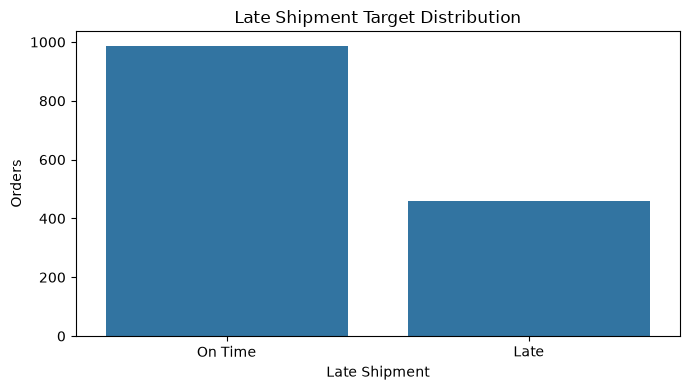

In [22]:
plt.figure(
    figsize=(7, 4)
)

sns.countplot(
    data=orders,
    x="is_late"
)

plt.title(
    "Late Shipment Target Distribution"
)

plt.xlabel(
    "Late Shipment"
)

plt.ylabel(
    "Orders"
)

plt.xticks(
    [0, 1],
    [
        "On Time",
        "Late"
    ]
)

plt.tight_layout()
plt.show()

## 2. Explore Late Shipment Patterns

Before creating model features, we explore how late shipment risk changes over time.

We first examine:

- monthly order volume
- monthly late shipment rate
- the number of late and on-time orders

This helps us understand whether shipment risk is stable over time.

In [24]:
orders["order_month"] = (
    orders["order_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_late_summary = (
    orders.groupby(
        "order_month",
        observed=True
    )
    .agg(
        orders=(
            "order_id",
            "count"
        ),
        late_orders=(
            "is_late",
            "sum"
        ),
        late_rate=(
            "is_late",
            "mean"
        )
    )
    .reset_index()
)

monthly_late_summary["late_rate_pct"] = (
    monthly_late_summary["late_rate"]
    * 100
)

monthly_late_summary["on_time_orders"] = (
    monthly_late_summary["orders"]
    - monthly_late_summary["late_orders"]
)

monthly_late_summary

,order_month,orders,late_orders,late_rate,late_rate_pct,on_time_orders
0,2016-01-01,50,13,0.260,26.000,37
1,2016-02-01,47,16,0.340,34.043,31
2,2016-03-01,55,11,0.200,20.000,44
3,2016-04-01,41,17,0.415,41.463,24
4,2016-05-01,49,15,0.306,30.612,34
5,2016-06-01,44,13,0.295,29.545,31
6,2016-07-01,50,15,0.300,30.000,35
7,2016-08-01,59,20,0.339,33.898,39
8,2016-09-01,66,17,0.258,25.758,49
9,2016-10-01,64,22,0.344,34.375,42


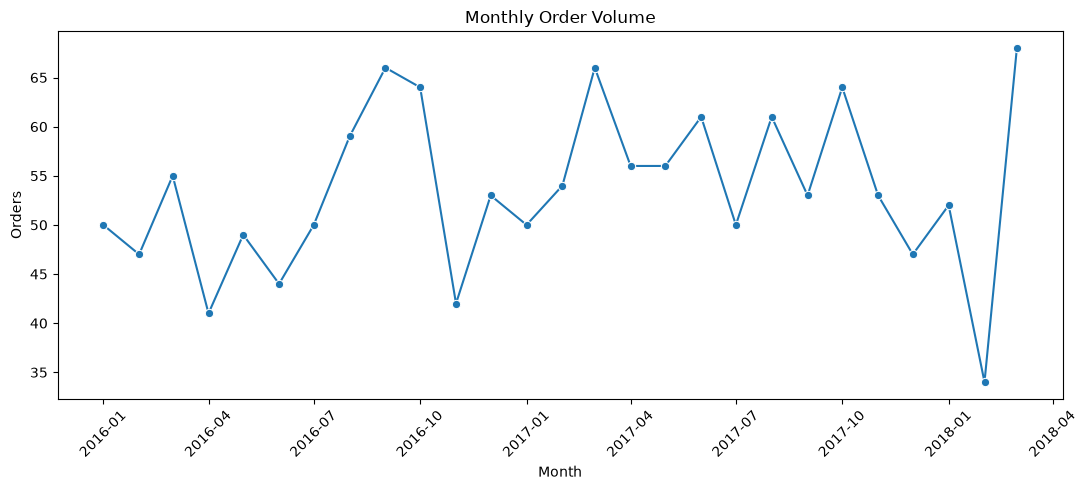

In [25]:
plt.figure(figsize = (11,5))

sns.lineplot(
    data = monthly_late_summary,
    x = "order_month",
    y = "orders",
    marker = "o"
)

plt.title(
    "Monthly Order Volume"
)

plt.xlabel("Month")
plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

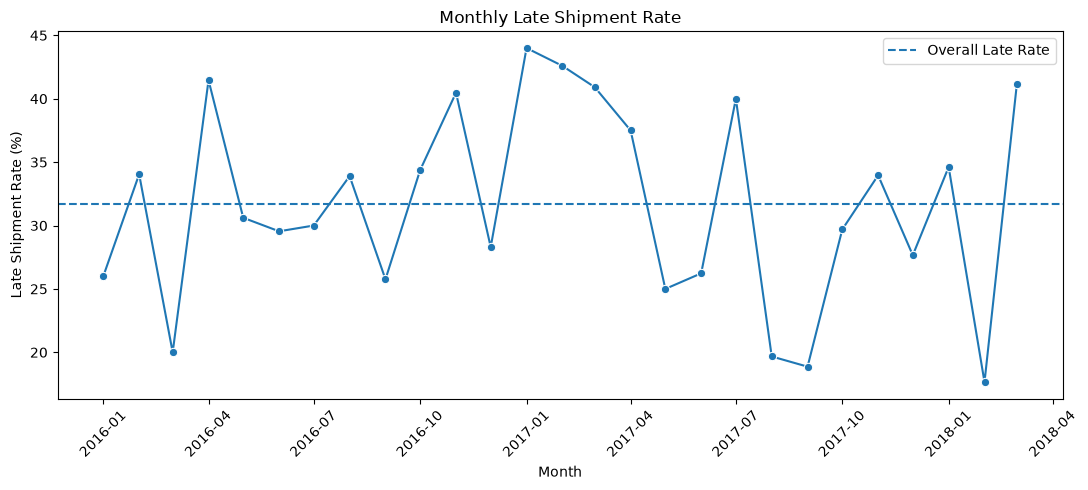

In [26]:
plt.figure(figsize=(11, 5))

sns.lineplot(
    data=monthly_late_summary,
    x="order_month",
    y="late_rate_pct",
    marker="o"
)

plt.axhline(
    orders["is_late"].mean() * 100,
    linestyle="--",
    label="Overall Late Rate"
)

plt.title(
    "Monthly Late Shipment Rate"
)

plt.xlabel("Month")
plt.ylabel("Late Shipment Rate (%)")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

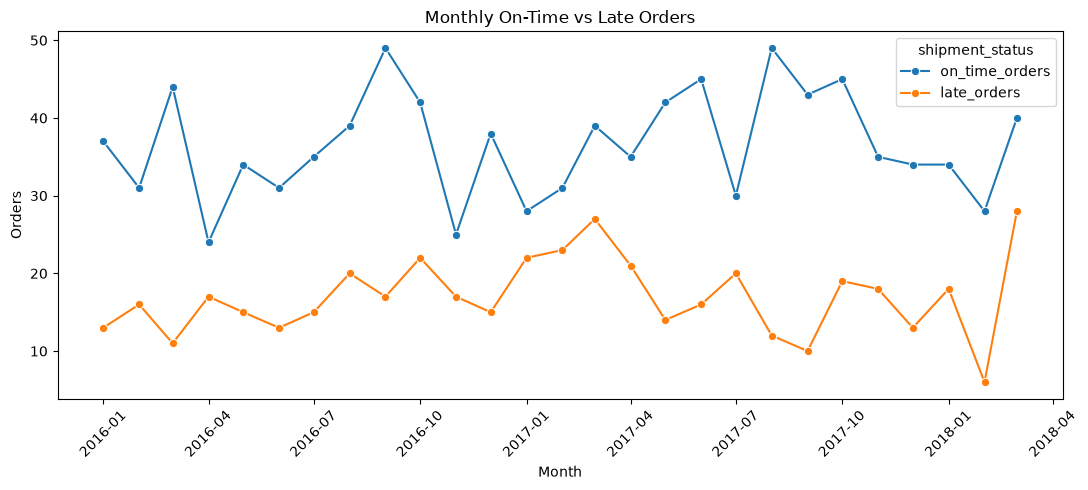

In [27]:
monthly_status = (
    monthly_late_summary[
        [
            "order_month",
            "on_time_orders",
            "late_orders"
        ]
    ]
    .melt(
        id_vars = "order_month",
        var_name = "shipment_status",
        value_name = "orders"
    )
)

plt.figure(figsize=(11, 5))

sns.lineplot(
    data=monthly_status,
    x="order_month",
    y="orders",
    hue="shipment_status",
    marker="o"
)

plt.title(
    "Monthly On-Time vs Late Orders"
)

plt.xlabel("Month")
plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [28]:
monthly_late_summary[
    "late_rate_pct"
].describe()

count   27.000
mean    31.629
std      7.789
min     17.647
25%     26.115
50%     30.612
75%     38.750
max     44.000
Name: late_rate_pct, dtype: float64

In [29]:
display(
    monthly_late_summary
    .nsmallest(
        5,
        "late_rate_pct"
    )
)

display(
    monthly_late_summary
    .nlargest(
        5,
        "late_rate_pct"
    )
)

,order_month,orders,late_orders,late_rate,late_rate_pct,on_time_orders
25,2018-02-01,34,6,0.176,17.647,28
20,2017-09-01,53,10,0.189,18.868,43
19,2017-08-01,61,12,0.197,19.672,49
2,2016-03-01,55,11,0.200,20.000,44
16,2017-05-01,56,14,0.250,25.000,42


,order_month,orders,late_orders,late_rate,late_rate_pct,on_time_orders
12,2017-01-01,50,22,0.440,44.000,28
13,2017-02-01,54,23,0.426,42.593,31
3,2016-04-01,41,17,0.415,41.463,24
26,2018-03-01,68,28,0.412,41.176,40
14,2017-03-01,66,27,0.409,40.909,39


### Time-Based Findings

The overall late shipment rate is approximately 31.7%.

Monthly late shipment rates vary across the analysis period.

The lowest monthly rate is around 17.6%, while the highest rate is 44.0%.

There is no clear long-term increasing or decreasing trend.

Some periods show temporary increases in late shipment risk, especially in early 2017.

Calendar features may provide useful information, but time alone does not explain late shipment risk.

### Store and Staff Patterns

Shipment performance may differ across stores and staff members.

We will compare:

- order volume
- number of late orders
- late shipment rate

These variables are known when the order is created and can be used as model features.

In [30]:
store_late_summary = (
    orders.groupby(
        [
            "store_id",
            "store_name"
        ],
        observed = True
    )
    .agg(
        orders = (
            "order_id",
            "count"
        ),
        late_orders=(
            "is_late",
            "sum"
        ),
        late_rate=(
            "is_late",
            "mean"
        )
    )
    .reset_index()
)

store_late_summary["late_rate_pct"] = (
    store_late_summary["late_rate"]
    * 100
)

store_late_summary = (
    store_late_summary
    .sort_values(
        "late_rate_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

store_late_summary

,store_id,store_name,orders,late_orders,late_rate,late_rate_pct
0,1,Santa Cruz Bikes,284,104,0.366,36.620
1,2,Baldwin Bikes,1019,317,0.311,31.109
2,3,Rowlett Bikes,142,37,0.261,26.056


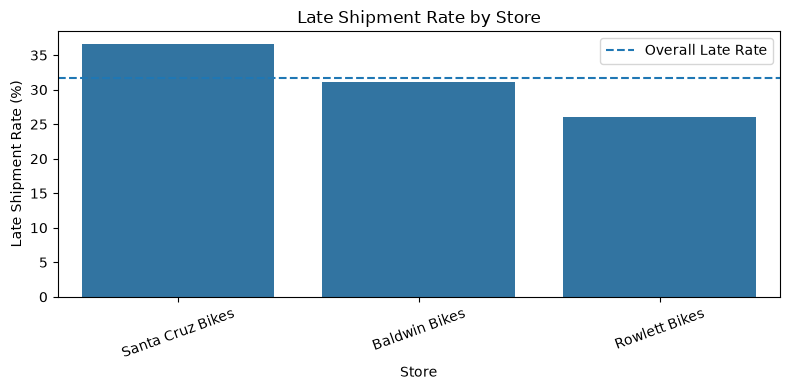

In [31]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=store_late_summary,
    x="store_name",
    y="late_rate_pct"
)

plt.axhline(
    orders["is_late"].mean() * 100,
    linestyle="--",
    label="Overall Late Rate"
)

plt.title(
    "Late Shipment Rate by Store"
)

plt.xlabel("Store")
plt.ylabel("Late Shipment Rate (%)")

plt.xticks(rotation=20)
plt.legend()

plt.tight_layout()
plt.show()

In [33]:
staff_late_summary = (
    orders.groupby(
        [
            "staff_id",
            "staff_name",
            "store_name"
        ],
        observed=True
    )
    .agg(
        orders=(
            "order_id",
            "count"
        ),
        late_orders=(
            "is_late",
            "sum"
        ),
        late_rate=(
            "is_late",
            "mean"
        )
    )
    .reset_index()
)

staff_late_summary["late_rate_pct"] = (
    staff_late_summary["late_rate"]
    * 100
)

staff_late_summary = (
    staff_late_summary
    .sort_values(
        "late_rate_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

staff_late_summary

,staff_id,staff_name,store_name,orders,late_orders,late_rate,late_rate_pct
0,2,Mireya Copeland,Santa Cruz Bikes,137,60,0.438,43.796
1,6,Marcelene Boyer,Baldwin Bikes,521,167,0.321,32.054
2,7,Venita Daniel,Baldwin Bikes,498,150,0.301,30.120
3,3,Genna Serrano,Santa Cruz Bikes,147,44,0.299,29.932
4,9,Layla Terrell,Rowlett Bikes,71,20,0.282,28.169
5,8,Kali Vargas,Rowlett Bikes,71,17,0.239,23.944


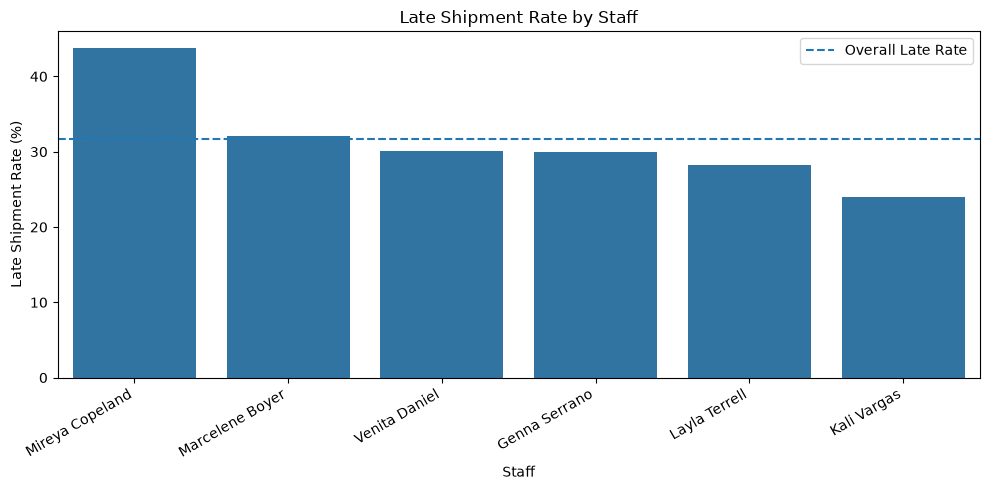

In [34]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=staff_late_summary,
    x="staff_name",
    y="late_rate_pct"
)

plt.axhline(
    orders["is_late"].mean() * 100,
    linestyle="--",
    label="Overall Late Rate"
)

plt.title(
    "Late Shipment Rate by Staff"
)

plt.xlabel("Staff")
plt.ylabel("Late Shipment Rate (%)")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.legend()

plt.tight_layout()
plt.show()

In [35]:
staff_late_summary[
    [
        "staff_name",
        "orders"
    ]
].sort_values(
    "orders"
)

,staff_name,orders
4,Layla Terrell,71
5,Kali Vargas,71
0,Mireya Copeland,137
3,Genna Serrano,147
2,Venita Daniel,498
1,Marcelene Boyer,521


In [36]:
staff_store_pivot = (
    staff_late_summary.pivot_table(
        index = "staff_name",
        columns = "store_name",
        values = "late_rate_pct"
    )
)

staff_store_pivot

store_name,Baldwin Bikes,Rowlett Bikes,Santa Cruz Bikes
staff_name,,,
Genna Serrano,NaN,NaN,29.932
Kali Vargas,NaN,23.944,NaN
Layla Terrell,NaN,28.169,NaN
Marcelene Boyer,32.054,NaN,NaN
Mireya Copeland,NaN,NaN,43.796
Venita Daniel,30.120,NaN,NaN


### Store and Staff Findings

Late shipment rates differ across stores.

Santa Cruz Bikes has the highest late shipment rate, while Rowlett Bikes has the lowest.

Shipment performance also differs across staff members.

Mireya Copeland has the highest observed late shipment rate.

However, each staff member belongs to only one store.

This means that store and staff information are related and their effects should be interpreted carefully.

Both variables will remain candidate model features.

### Required Lead Time

Required lead time is the number of days between the order date and the required delivery date.

This information is known when the order is created, so it can be safely used as a model feature.

A shorter lead time may increase shipment pressure and late shipment risk.

We will examine:

- the distribution of required lead time
- late shipment rate by lead time
- actual shipping time by lead time
- differences between late and on-time orders

In [37]:
orders[
    "required_lead_days"
].describe()

count   1445.000
mean       1.997
std        0.826
min        1.000
25%        1.000
50%        2.000
75%        3.000
max        3.000
Name: required_lead_days, dtype: float64

In [38]:
lead_time_counts = (
    orders[
        "required_lead_days"
    ]
    .value_counts()
    .sort_index()
)

lead_time_counts

required_lead_days
1    495
2    459
3    491
Name: count, dtype: int64

Late shipment rate based on lead time

In [39]:
lead_time_summary = (
    orders.groupby(
        "required_lead_days",
        observed=True
    )
    .agg(
        orders=(
            "order_id",
            "count"
        ),
        late_orders=(
            "is_late",
            "sum"
        ),
        late_rate=(
            "is_late",
            "mean"
        )
    )
    .reset_index()
)

lead_time_summary[
    "late_rate_pct"
] = (
    lead_time_summary["late_rate"]
    * 100
)

lead_time_summary

,required_lead_days,orders,late_orders,late_rate,late_rate_pct
0,1,495,322,0.651,65.051
1,2,459,136,0.296,29.630
2,3,491,0,0.000,0.000


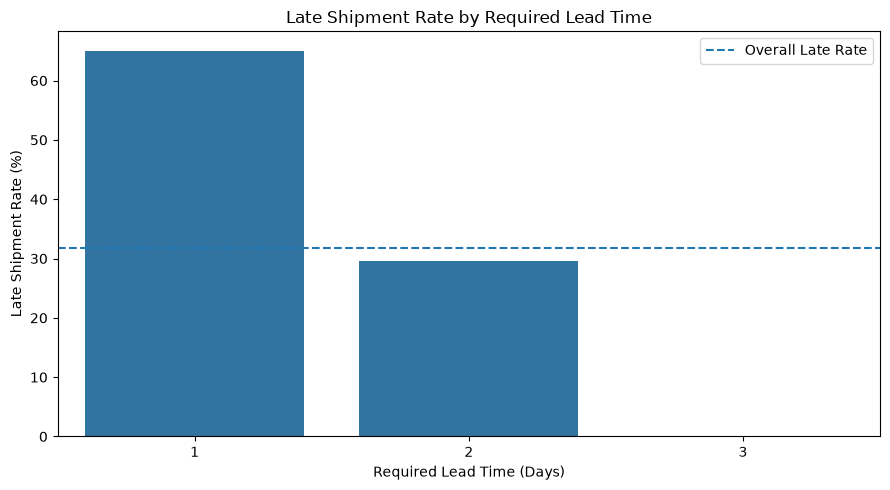

In [40]:
plt.figure(
    figsize=(9, 5)
)

sns.barplot(
    data=lead_time_summary,
    x="required_lead_days",
    y="late_rate_pct"
)

plt.axhline(
    orders["is_late"].mean() * 100,
    linestyle="--",
    label="Overall Late Rate"
)

plt.title(
    "Late Shipment Rate by Required Lead Time"
)

plt.xlabel(
    "Required Lead Time (Days)"
)

plt.ylabel(
    "Late Shipment Rate (%)"
)

plt.legend()

plt.tight_layout()
plt.show()

In [41]:
lead_shipping_summary = (
    orders.groupby(
        "required_lead_days",
        observed=True
    )
    .agg(
        orders=(
            "order_id",
            "count"
        ),
        avg_shipping_days=(
            "shipping_days",
            "mean"
        ),
        median_shipping_days=(
            "shipping_days",
            "median"
        ),
        avg_delay_days=(
            "delay_days",
            "mean"
        ),
        late_rate=(
            "is_late",
            "mean"
        )
    )
    .reset_index()
)

lead_shipping_summary[
    "late_rate_pct"
] = (
    lead_shipping_summary[
        "late_rate"
    ]
    * 100
)

lead_shipping_summary

,required_lead_days,orders,avg_shipping_days,median_shipping_days,avg_delay_days,late_rate,late_rate_pct
0,1,495,1.960,2.000,0.960,0.651,65.051
1,2,459,1.937,2.000,0.296,0.296,29.630
2,3,491,2.047,2.000,0.000,0.000,0.000


Let's compare late and on-time orders.

In [42]:
lead_time_by_status = (
    orders.groupby(
        "is_late"
    )[
        "required_lead_days"
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )
)

lead_time_by_status

,count,mean,median,std,min,max
is_late,,,,,,
0,987,2.322,2.000,0.755,1,3
1,458,1.297,1.000,0.457,1,2


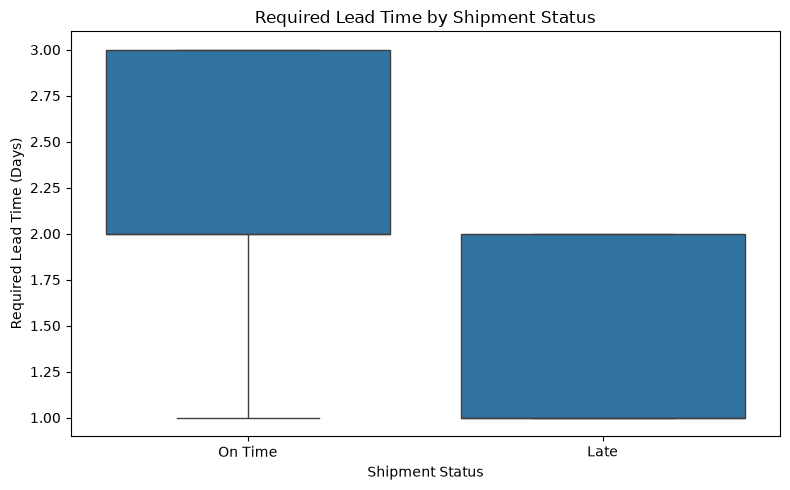

In [43]:
plt.figure(
    figsize=(8, 5)
)

sns.boxplot(
    data=orders,
    x="is_late",
    y="required_lead_days"
)

plt.title(
    "Required Lead Time by Shipment Status"
)

plt.xlabel(
    "Shipment Status"
)

plt.ylabel(
    "Required Lead Time (Days)"
)

plt.xticks(
    [0, 1],
    [
        "On Time",
        "Late"
    ]
)

plt.tight_layout()
plt.show()

### Required Lead Time Findings

Required lead time has a strong relationship with late shipment risk.

The dataset contains three lead-time levels:

- 1 day
- 2 days
- 3 days

Late shipment risk decreases sharply as the required lead time increases.

- 1-day lead time: 65.1% late
- 2-day lead time: 29.6% late
- 3-day lead time: 0.0% late

Average actual shipping time remains close to 2 days across all three groups.

This suggests that the main difference comes from the allowed delivery window rather than large changes in actual shipping speed.

Required lead time will therefore be an important model feature.

### Order Size and Complexity

Larger or more complex orders may require more preparation before shipment.

We will examine three order-level variables:

- line item count
- number of distinct products
- total units

All three variables are known when the order is created and can be safely used as model features.

We will compare their distributions between on-time and late orders and check whether larger orders have higher late shipment risk.

In [44]:
order_size_columns = [
    "line_item_count",
    "distinct_products",
    "total_units"
]

orders[
    order_size_columns
].describe()

,line_item_count,distinct_products,total_units
count,1445.000,1445.000,1445.000
mean,2.916,2.916,4.372
std,1.317,1.317,2.142
min,1.000,1.000,1.000
25%,2.000,2.000,3.000
50%,3.000,3.000,4.000
75%,4.000,4.000,6.000
max,5.000,5.000,10.000


In [45]:
for column in order_size_columns:

    print(
        f"{column}: "
        f"{orders[column].nunique()} unique values"
    )

    print(
        orders[column]
        .value_counts()
        .sort_index()
        .head(20)
    )

    print()

line_item_count: 5 unique values
line_item_count
1    259
2    331
3    337
4    308
5    210
Name: count, dtype: int64

distinct_products: 5 unique values
distinct_products
1    259
2    331
3    337
4    308
5    210
Name: count, dtype: int64

total_units: 10 unique values
total_units
1.000     133
2.000     214
3.000     187
4.000     247
5.000     201
6.000     201
7.000     137
8.000      91
9.000      30
10.000      4
Name: count, dtype: int64



Comparison based on shipment status

In [46]:
order_size_by_status = (
    orders.groupby(
        "is_late"
    )[
        order_size_columns
    ]
    .agg(
        [
            "mean",
            "median",
            "std"
        ]
    )
)

order_size_by_status


line_item_count              distinct_products               \
                   mean median   std              mean median   std   
is_late                                                               
0                 2.901  3.000 1.310             2.901  3.000 1.310   
1                 2.950  3.000 1.333             2.950  3.000 1.333   

        total_units               
               mean median   std  
is_late                           
0             4.350  4.000 2.127  
1             4.421  4.000 2.176

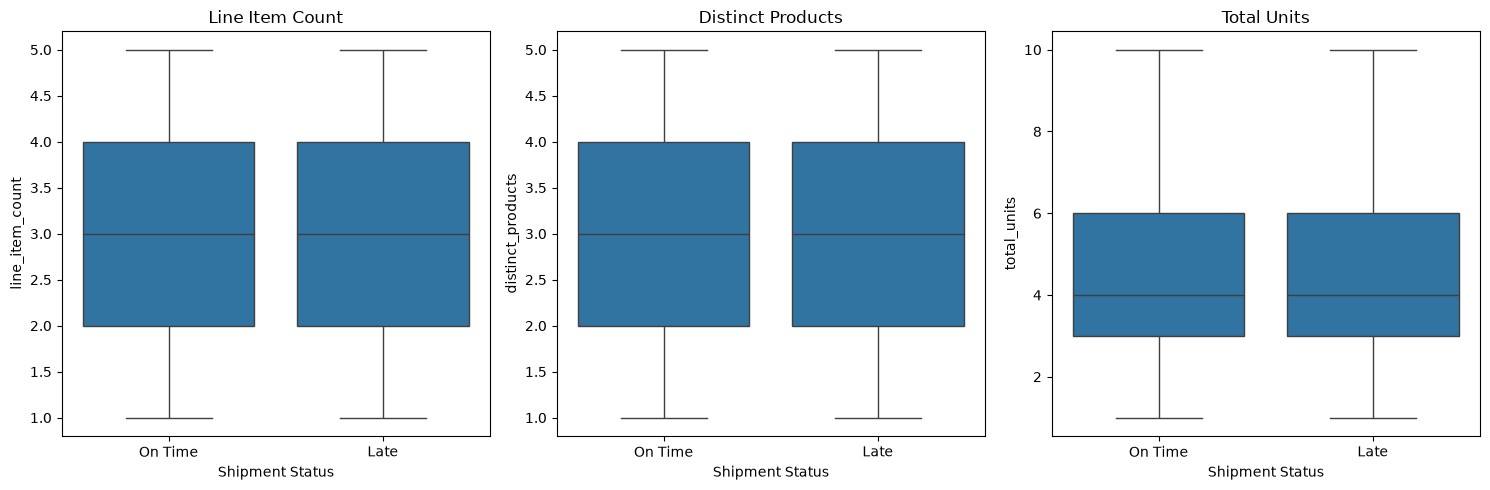

In [47]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,5)
)

for ax, column in zip(
    axes,
    order_size_columns
):

    sns.boxplot(
        data = orders,
        x = "is_late",
        y = column,
        ax = ax
    )

    ax.set_title(
        column.replace(
            "_",
            " "
        ).title()
    )

    ax.set_xlabel(
        "Shipment Status"
    )

    ax.set_xticks(
        [0, 1],
        [
            "On Time",
            "Late"
        ]
    )

plt.tight_layout()
plt.show()

Late rate based on Total Units

In [48]:
orders[
    "total_units"
].value_counts().sort_index()

total_units
1.000     133
2.000     214
3.000     187
4.000     247
5.000     201
6.000     201
7.000     137
8.000      91
9.000      30
10.000      4
Name: count, dtype: int64

In [49]:
units_summary = (
    orders.groupby(
        "total_units",
        observed=True
    )
    .agg(
        orders=(
            "order_id",
            "count"
        ),
        late_orders=(
            "is_late",
            "sum"
        ),
        late_rate=(
            "is_late",
            "mean"
        )
    )
    .reset_index()
)

units_summary[
    "late_rate_pct"
] = (
    units_summary[
        "late_rate"
    ]
    * 100
)

units_summary

,total_units,orders,late_orders,late_rate,late_rate_pct
0,1.000,133,40,0.301,30.075
1,2.000,214,69,0.322,32.243
2,3.000,187,57,0.305,30.481
3,4.000,247,82,0.332,33.198
4,5.000,201,58,0.289,28.856
5,6.000,201,66,0.328,32.836
6,7.000,137,42,0.307,30.657
7,8.000,91,30,0.330,32.967
8,9.000,30,12,0.400,40.000
9,10.000,4,2,0.500,50.000


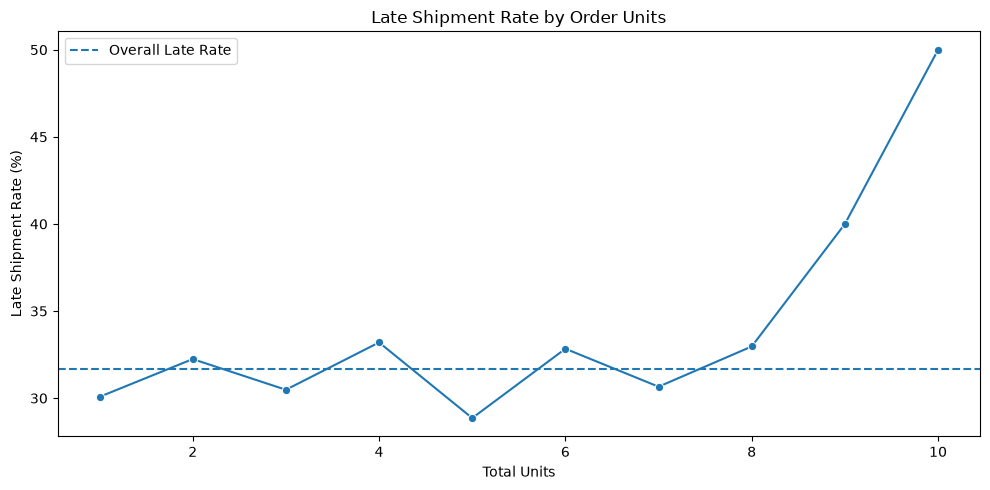

In [50]:
plt.figure(
    figsize=(10, 5)
)

sns.lineplot(
    data=units_summary,
    x="total_units",
    y="late_rate_pct",
    marker="o"
)

plt.axhline(
    orders["is_late"].mean() * 100,
    linestyle="--",
    label="Overall Late Rate"
)

plt.title(
    "Late Shipment Rate by Order Units"
)

plt.xlabel(
    "Total Units"
)

plt.ylabel(
    "Late Shipment Rate (%)"
)

plt.legend()

plt.tight_layout()
plt.show()

### Order Size and Complexity Findings

Order size does not show a strong relationship with late shipment risk.

On-time and late orders have very similar:

- line item counts
- numbers of distinct products
- total units

Late shipment rates are also relatively stable across most order sizes.

Orders with 9 or 10 units show higher late rates, but these groups contain few observations.

Therefore, order size may provide some additional model information, but it does not appear to be a major risk driver.

In [51]:
same_line_and_product_count = (
    orders["line_item_count"]
    == orders["distinct_products"]
).all()

print(
    "Line item count equals distinct products:",
    same_line_and_product_count
)

Line item count equals distinct products: True


In [52]:
(
    orders["line_item_count"]
    - orders["distinct_products"]
).value_counts()

0    1445
Name: count, dtype: int64

### Order Value and Discount

Order value and discount level may be related to shipment complexity or order priority.

We will examine:

- gross order value
- discount amount
- net order value
- effective discount percentage

These values are available when the order is created.

Realized sales values are not used because they depend on the completed order outcome.

In [53]:
value_columns = [
    "gross_order_value",
    "discount_amount",
    "net_order_value",
    "effective_discount_pct"
]

orders[
    value_columns
].describe()

,gross_order_value,discount_amount,net_order_value,effective_discount_pct
count,1445.000,1445.000,1445.000,1445.000
mean,5147.412,536.610,4610.802,10.526
std,4380.187,511.035,3951.872,4.373
min,109.990,5.500,104.490,5.000
25%,1767.970,171.000,1576.780,7.000
50%,3989.980,389.600,3540.360,9.520
75%,7319.950,736.500,6578.920,13.340
max,29150.910,3670.000,27050.710,20.000


In [54]:
order_value_by_status = (
    orders.groupby(
        "is_late"
    )[
        value_columns
    ]
    .agg(
        [
            "mean",
            "median",
            "std"
        ]
    )
)

order_value_by_status

gross_order_value                   discount_amount                  \
                     mean   median      std            mean  median     std   
is_late                                                                       
0                5219.158 3908.960 4578.633         538.606 386.600 526.307   
1                4992.798 4023.470 3918.823         532.306 393.500 476.993   

        net_order_value                   effective_discount_pct               
                   mean   median      std                   mean median   std  
is_late                                                                        
0              4680.551 3486.410 4135.768                 10.455  9.520 4.346  
1              4460.491 3606.855 3522.703                 10.679  9.630 4.430

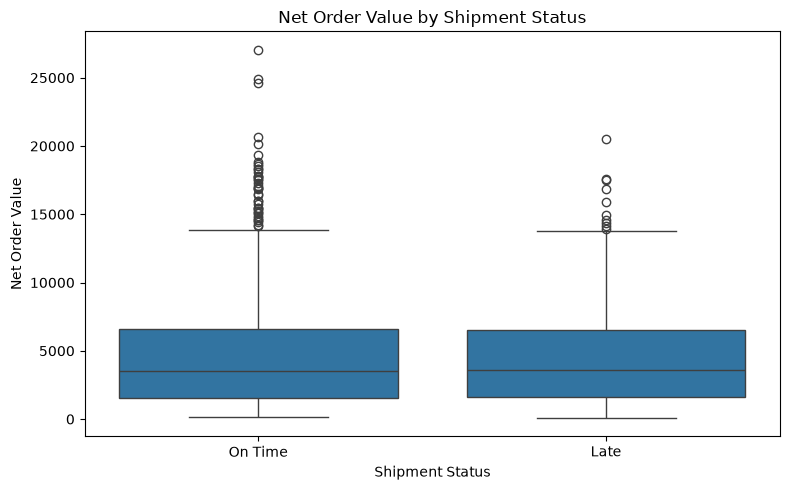

In [55]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=orders,
    x="is_late",
    y="net_order_value"
)

plt.title(
    "Net Order Value by Shipment Status"
)

plt.xlabel(
    "Shipment Status"
)

plt.ylabel(
    "Net Order Value"
)

plt.xticks(
    [0, 1],
    [
        "On Time",
        "Late"
    ]
)

plt.tight_layout()
plt.show()

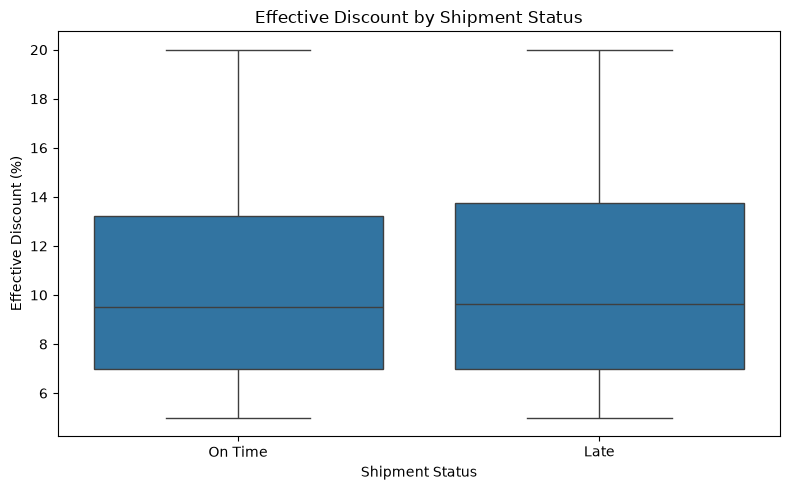

In [56]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=orders,
    x="is_late",
    y="effective_discount_pct"
)

plt.title(
    "Effective Discount by Shipment Status"
)

plt.xlabel(
    "Shipment Status"
)

plt.ylabel(
    "Effective Discount (%)"
)

plt.xticks(
    [0, 1],
    [
        "On Time",
        "Late"
    ]
)

plt.tight_layout()
plt.show()

In [57]:
orders[
    "effective_discount_pct"
].value_counts().sort_index()

effective_discount_pct
5.000     96
5.090      1
5.100      3
5.130      1
5.140      2
          ..
19.430     1
19.480     1
19.540     1
19.700     1
20.000    91
Name: count, Length: 706, dtype: int64

Are the monetary columns repetitions of each other?

In [58]:
value_correlation = (
    orders[
        value_columns
    ]
    .corr()
)

value_correlation

,gross_order_value,discount_amount,net_order_value,effective_discount_pct
gross_order_value,1.000,0.855,0.998,-0.027
discount_amount,0.855,1.000,0.819,0.362
net_order_value,0.998,0.819,1.000,-0.077
effective_discount_pct,-0.027,0.362,-0.077,1.000


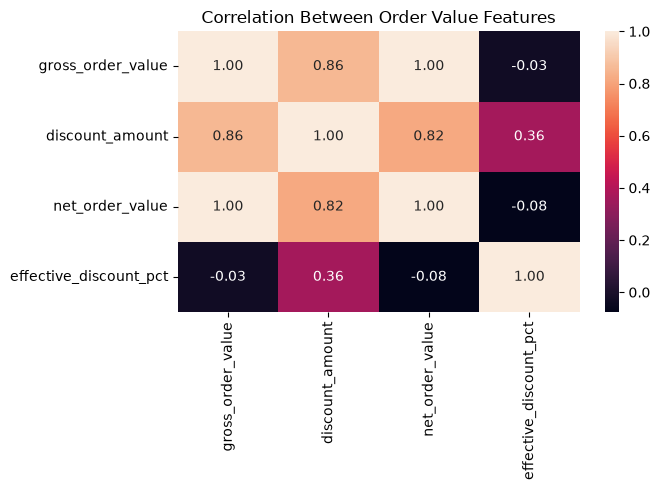

In [59]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    value_correlation,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Correlation Between Order Value Features"
)

plt.tight_layout()
plt.show()

### Order Size and Value Findings

Order size and order value do not show a strong relationship with late shipment risk.

On-time and late orders have very similar:

- numbers of products
- total units
- order values
- discount percentages

Line item count and distinct product count are identical for every order.

Therefore, only one of these two variables is needed.

Gross order value and net order value are also almost perfectly correlated.

To reduce redundant information, the final feature set will prefer:

- distinct products
- total units
- net order value
- effective discount percentage

These variables may still provide additional model information, but they do not appear to be major late-shipment drivers.

### Customer Geography

Shipment risk may differ across customer locations.

Longer or more complex delivery routes may create different shipment patterns.

We will examine:

- customer state
- customer city
- order volume by location
- late shipment rate by location

Customer ID will not be used because every customer appears only once in the dataset.

In [60]:
print(
    f"Customer states : "
    f"{orders['customer_state'].nunique()}"
)

print(
    f"Customer cities : "
    f"{orders['customer_city'].nunique()}"
)

Customer states : 3
Customer cities : 195


In [61]:
state_summary = (
    orders.groupby(
        "customer_state",
        observed=True
    )
    .agg(
        orders=(
            "order_id",
            "count"
        ),
        late_orders=(
            "is_late",
            "sum"
        ),
        late_rate=(
            "is_late",
            "mean"
        )
    )
    .reset_index()
)

state_summary[
    "late_rate_pct"
] = (
    state_summary["late_rate"]
    * 100
)

state_summary = (
    state_summary
    .sort_values(
        "orders",
        ascending=False
    )
    .reset_index(drop=True)
)

state_summary

,customer_state,orders,late_orders,late_rate,late_rate_pct
0,NY,1019,317,0.311,31.109
1,CA,284,104,0.366,36.620
2,TX,142,37,0.261,26.056


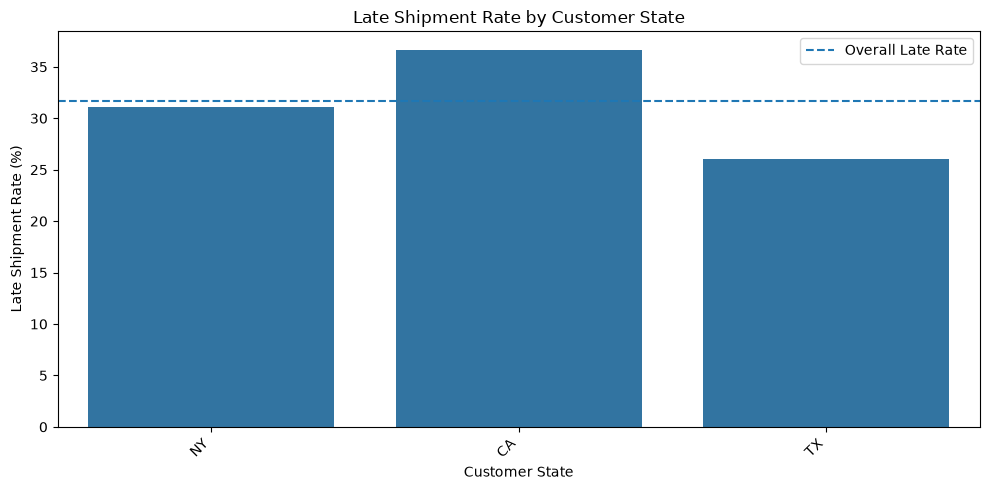

In [62]:
plt.figure(
    figsize=(10, 5)
)

sns.barplot(
    data=state_summary,
    x="customer_state",
    y="late_rate_pct"
)

plt.axhline(
    orders["is_late"].mean() * 100,
    linestyle="--",
    label="Overall Late Rate"
)

plt.title(
    "Late Shipment Rate by Customer State"
)

plt.xlabel(
    "Customer State"
)

plt.ylabel(
    "Late Shipment Rate (%)"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend()

plt.tight_layout()
plt.show()

In [63]:
city_summary = (
    orders.groupby(
        "customer_city",
        observed=True
    )
    .agg(
        orders=(
            "order_id",
            "count"
        ),
        late_orders=(
            "is_late",
            "sum"
        ),
        late_rate=(
            "is_late",
            "mean"
        )
    )
    .reset_index()
)

city_summary[
    "late_rate_pct"
] = (
    city_summary["late_rate"]
    * 100
)

city_summary = (
    city_summary
    .sort_values(
        "orders",
        ascending=False
    )
    .reset_index(drop=True)
)

city_summary.head(20)

,customer_city,orders,late_orders,late_rate,late_rate_pct
0,Mount Vernon,20,7,0.350,35.000
1,Ballston Spa,17,4,0.235,23.529
2,Scarsdale,17,6,0.353,35.294
3,Canandaigua,14,6,0.429,42.857
4,Ossining,13,7,0.538,53.846
5,Longview,13,1,0.077,7.692
6,Floral Park,13,6,0.462,46.154
7,Canyon Country,12,4,0.333,33.333
8,Merrick,12,3,0.250,25.000
9,Howard Beach,12,4,0.333,33.333


In [64]:
city_summary[
    "orders"
].describe()

count   195.000
mean      7.410
std       3.015
min       1.000
25%       5.000
50%       7.000
75%       9.000
max      20.000
Name: orders, dtype: float64

In [65]:
city_summary[
    city_summary["orders"] >= 10
].sort_values(
    "late_rate_pct",
    ascending=False
)

,customer_city,orders,late_orders,late_rate,late_rate_pct
22,South El Monte,11,8,0.727,72.727
28,Woodside,10,6,0.600,60.000
26,Anaheim,11,6,0.545,54.545
4,Ossining,13,7,0.538,53.846
33,Euless,10,5,0.500,50.000
14,Smithtown,12,6,0.500,50.000
43,Port Washington,10,5,0.500,50.000
38,Shirley,10,5,0.500,50.000
37,Oxnard,10,5,0.500,50.000
6,Floral Park,13,6,0.462,46.154


In [66]:
store_state_check = pd.crosstab(
    orders["store_name"],
    orders["customer_state"]
)

store_state_check

customer_state,CA,NY,TX
store_name,,,
Baldwin Bikes,0,1019,0
Rowlett Bikes,0,0,142
Santa Cruz Bikes,284,0,0


In [67]:
pd.crosstab(
    orders["store_name"],
    orders["region"]
)

region,CA,NY,TX
store_name,,,
Baldwin Bikes,0,1019,0
Rowlett Bikes,0,0,142
Santa Cruz Bikes,284,0,0


### Customer Geography Findings

Customer state and region are fully determined by store.

Each store serves customers from only one state and region in this dataset:

- Baldwin Bikes → NY
- Rowlett Bikes → TX
- Santa Cruz Bikes → CA

Therefore, customer state and region do not provide additional information beyond the store feature.

To avoid redundant features:

- store will be kept
- customer state will be excluded
- region will be excluded

Customer city will also be excluded from the initial model because it has high cardinality and relatively few observations per city.

### Calendar Features

Late shipment risk may change across different periods of the year or days of the week.

Calendar information is known when the order is created and can be safely used as model input.

We will examine:

- month of year
- quarter
- day of week
- weekend orders

These features may capture recurring operational patterns.

In [68]:
orders["order_year"] = (
    orders["order_date"]
    .dt.year
)

orders["order_month_number"] = (
    orders["order_date"]
    .dt.month
)

orders["order_quarter"] = (
    orders["order_date"]
    .dt.quarter
)

orders["order_dayofweek"] = (
    orders["order_date"]
    .dt.dayofweek
)

orders["order_day_name"] = (
    orders["order_date"]
    .dt.day_name()
)

orders["is_weekend_order"] = (
    orders["order_dayofweek"] >= 5
).astype("int8")

In [69]:
month_summary = (
    orders.groupby(
        "order_month_number",
        observed=True
    )
    .agg(
        orders=(
            "order_id",
            "count"
        ),
        late_orders=(
            "is_late",
            "sum"
        ),
        late_rate=(
            "is_late",
            "mean"
        )
    )
    .reset_index()
)

month_summary["late_rate_pct"] = (
    month_summary["late_rate"]
    * 100
)

month_summary

,order_month_number,orders,late_orders,late_rate,late_rate_pct
0,1,152,53,0.349,34.868
1,2,135,45,0.333,33.333
2,3,189,66,0.349,34.921
3,4,97,38,0.392,39.175
4,5,105,29,0.276,27.619
5,6,105,29,0.276,27.619
6,7,100,35,0.350,35.000
7,8,120,32,0.267,26.667
8,9,119,27,0.227,22.689
9,10,128,41,0.320,32.031


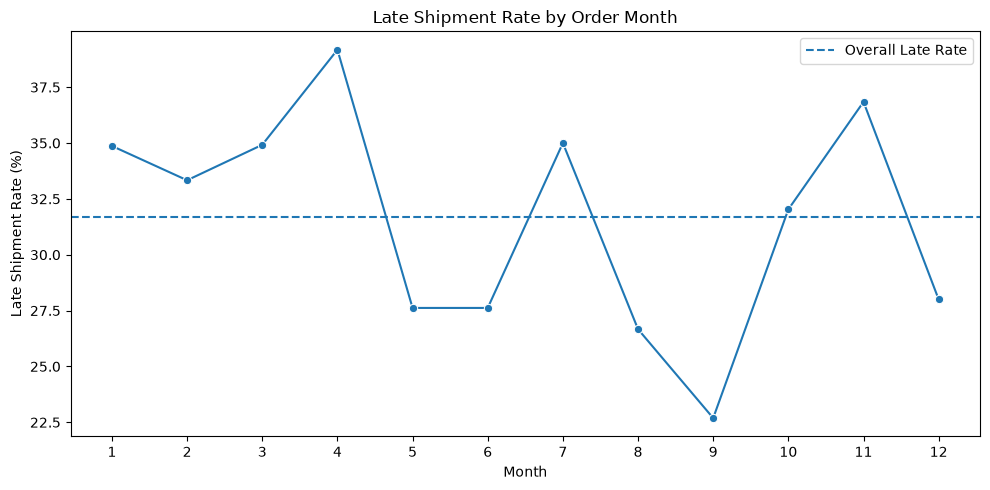

In [70]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=month_summary,
    x="order_month_number",
    y="late_rate_pct",
    marker="o"
)

plt.axhline(
    orders["is_late"].mean() * 100,
    linestyle="--",
    label="Overall Late Rate"
)

plt.title(
    "Late Shipment Rate by Order Month"
)

plt.xlabel("Month")
plt.ylabel("Late Shipment Rate (%)")

plt.xticks(range(1, 13))

plt.legend()

plt.tight_layout()
plt.show()

In [71]:
quarter_summary = (
    orders.groupby(
        "order_quarter",
        observed=True
    )
    .agg(
        orders=(
            "order_id",
            "count"
        ),
        late_orders=(
            "is_late",
            "sum"
        ),
        late_rate=(
            "is_late",
            "mean"
        )
    )
    .reset_index()
)

quarter_summary["late_rate_pct"] = (
    quarter_summary["late_rate"]
    * 100
)

quarter_summary

,order_quarter,orders,late_orders,late_rate,late_rate_pct
0,1,476,164,0.345,34.454
1,2,307,96,0.313,31.270
2,3,339,94,0.277,27.729
3,4,323,104,0.322,32.198


In [72]:
day_summary = (
    orders.groupby(
        [
            "order_dayofweek",
            "order_day_name"
        ],
        observed=True
    )
    .agg(
        orders=(
            "order_id",
            "count"
        ),
        late_orders=(
            "is_late",
            "sum"
        ),
        late_rate=(
            "is_late",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "order_dayofweek"
    )
)

day_summary["late_rate_pct"] = (
    day_summary["late_rate"]
    * 100
)

day_summary

,order_dayofweek,order_day_name,orders,late_orders,late_rate,late_rate_pct
0,0,Monday,213,75,0.352,35.211
1,1,Tuesday,188,52,0.277,27.660
2,2,Wednesday,196,66,0.337,33.673
3,3,Thursday,208,62,0.298,29.808
4,4,Friday,191,53,0.277,27.749
5,5,Saturday,210,67,0.319,31.905
6,6,Sunday,239,83,0.347,34.728


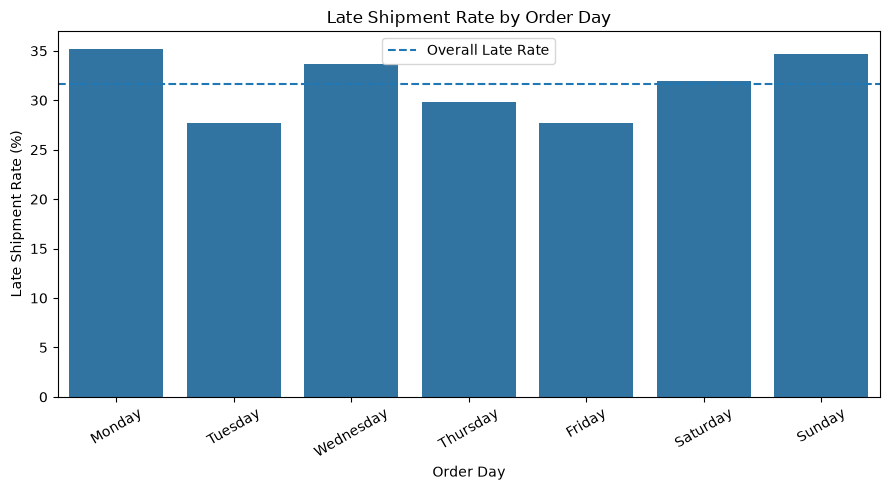

In [73]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=day_summary,
    x="order_day_name",
    y="late_rate_pct"
)

plt.axhline(
    orders["is_late"].mean() * 100,
    linestyle="--",
    label="Overall Late Rate"
)

plt.title(
    "Late Shipment Rate by Order Day"
)

plt.xlabel("Order Day")
plt.ylabel("Late Shipment Rate (%)")

plt.xticks(
    rotation=30
)

plt.legend()

plt.tight_layout()
plt.show()

In [74]:
weekend_summary = (
    orders.groupby(
        "is_weekend_order",
        observed=True
    )
    .agg(
        orders=(
            "order_id",
            "count"
        ),
        late_orders=(
            "is_late",
            "sum"
        ),
        late_rate=(
            "is_late",
            "mean"
        )
    )
    .reset_index()
)

weekend_summary["late_rate_pct"] = (
    weekend_summary["late_rate"]
    * 100
)

weekend_summary

,is_weekend_order,orders,late_orders,late_rate,late_rate_pct
0,0,996,308,0.309,30.924
1,1,449,150,0.334,33.408


### Calendar Findings

Late shipment risk changes moderately across calendar periods.

Some months and weekdays show higher late shipment rates, but the differences are much smaller than the effect of required lead time.

Quarter is derived from month, and weekend status is derived from day of week.

To avoid redundant features, the initial model will use:

- order month
- order day of week

Quarter and weekend indicators will not be included in the initial feature set.

## 3. Create Model Features

The final feature set contains only information available when the order is created.

Post-shipment information is excluded to prevent target leakage.

Redundant features identified during exploratory analysis are also removed.

In [75]:
CATEGORICAL_FEATURES = [
    "store_id",
    "staff_id",
    "order_month_number",
    "order_dayofweek"
]

NUMERICAL_FEATURES = [
    "required_lead_days",
    "distinct_products",
    "total_units",
    "net_order_value",
    "effective_discount_pct"
]

MODEL_FEATURES = (
    CATEGORICAL_FEATURES
    + NUMERICAL_FEATURES
)

TARGET = "is_late"

### Final Initial Feature Set

The initial model uses:

**Categorical features**

- store
- staff
- order month
- order day of week

**Numerical features**

- required lead days
- distinct products
- total units
- net order value
- effective discount percentage

Several columns are excluded because they are redundant, high-cardinality, or unavailable at prediction time.

Shipment outcome variables such as shipped date, shipping days, and delay days are excluded because they would cause target leakage.

### Time-Based Data Split

The model will be evaluated on later orders.

We use a chronological split:

- Train: January 2016 to September 2017
- Validation: October 2017 to December 2017
- Test: January 2018 to March 2018

The validation set will be used for model selection and threshold selection.

The test set will remain untouched until the final evaluation.

In [76]:
TRAIN_END = pd.Timestamp("2017-09-30")

VALIDATION_START = pd.Timestamp("2017-10-01")
VALIDATION_END = pd.Timestamp("2017-12-31")

TEST_START = pd.Timestamp("2018-01-01")
TEST_END = pd.Timestamp("2018-03-31")

In [77]:
train_df = (
    orders[
        orders["order_date"]
        <= TRAIN_END
    ]
    .copy()
)

validation_df = (
    orders[
        orders["order_date"]
        .between(
            VALIDATION_START,
            VALIDATION_END
        )
    ]
    .copy()
)

test_df = (
    orders[
        orders["order_date"]
        .between(
            TEST_START,
            TEST_END
        )
    ]
    .copy()
)

In [78]:
split_summary = pd.DataFrame(
    [
        {
            "Split": "Train",
            "Start": train_df["order_date"].min(),
            "End": train_df["order_date"].max(),
            "Orders": len(train_df),
            "Late Orders": train_df["is_late"].sum(),
            "Late Rate": train_df["is_late"].mean() * 100
        },
        {
            "Split": "Validation",
            "Start": validation_df["order_date"].min(),
            "End": validation_df["order_date"].max(),
            "Orders": len(validation_df),
            "Late Orders": validation_df["is_late"].sum(),
            "Late Rate": validation_df["is_late"].mean() * 100
        },
        {
            "Split": "Test",
            "Start": test_df["order_date"].min(),
            "End": test_df["order_date"].max(),
            "Orders": len(test_df),
            "Late Orders": test_df["is_late"].sum(),
            "Late Rate": test_df["is_late"].mean() * 100
        }
    ]
)

split_summary

,Split,Start,End,Orders,Late Orders,Late Rate
0,Train,2016-01-01,2017-09-30,1127,356,31.588
1,Validation,2017-10-01,2017-12-31,164,50,30.488
2,Test,2018-01-01,2018-03-31,154,52,33.766


In [79]:
assert (
    train_df["order_date"].max()
    < validation_df["order_date"].min()
)

assert (
    validation_df["order_date"].max()
    < test_df["order_date"].min()
)

assert (
    len(train_df)
    + len(validation_df)
    + len(test_df)
    == len(orders)
)

In [80]:
pd.DataFrame({
    "train_unique": train_df[MODEL_FEATURES].nunique(),
    "validation_unique": validation_df[MODEL_FEATURES].nunique(),
    "test_unique": test_df[MODEL_FEATURES].nunique()
})

,train_unique,validation_unique,test_unique
store_id,3,3,3
staff_id,6,6,6
order_month_number,12,3,3
order_dayofweek,7,7,7
required_lead_days,3,3,3
distinct_products,5,5,5
total_units,10,9,9
net_order_value,1053,164,152
effective_discount_pct,596,120,113


### Split Validation

The late shipment rate is similar across train, validation, and test periods.

This suggests that there is no major target distribution shift between the three periods.

Before model training, we also check whether validation or test data contains categorical values that were not seen during training.

In [81]:
for column in CATEGORICAL_FEATURES:

    train_values = set(
        train_df[column].unique()
    )

    validation_values = set(
        validation_df[column].unique()
    )

    test_values = set(
        test_df[column].unique()
    )

    print(column)

    print(
        "Validation unseen:",
        validation_values - train_values
    )

    print(
        "Test unseen:",
        test_values - train_values
    )

    print()

store_id
Validation unseen: set()
Test unseen: set()

staff_id
Validation unseen: set()
Test unseen: set()

order_month_number
Validation unseen: set()
Test unseen: set()

order_dayofweek
Validation unseen: set()
Test unseen: set()



## 4. Compare Classification Models

We first create a simple baseline model.

Then we compare several classification algorithms using the validation period.

The main model-selection metric is:

**PR-AUC**

PR-AUC is useful because the positive class, late shipment, represents about one-third of all orders.

We will also report:

- ROC-AUC
- Precision
- Recall
- F1 Score
- F2 Score

The test period will not be used during model selection.

In [82]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

### Preprocessing

Categorical features are one-hot encoded.

Numerical features are standardized for models such as Logistic Regression.

The preprocessing steps are fitted only on the training data.

In [83]:
categorical_transformer  = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

numerical_transformer  = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers = [
        (
            "categorical",
            categorical_transformer,
            CATEGORICAL_FEATURES
        ),
        (
            "numerical",
            numerical_transformer,
            NUMERICAL_FEATURES
        )
    ]
)

In [84]:
X_train = train_df[
    MODEL_FEATURES
].copy()

y_train = train_df[
    TARGET
].copy()

X_validation = validation_df[
    MODEL_FEATURES
].copy()

y_validation = validation_df[
    TARGET
].copy()

X_test = test_df[
    MODEL_FEATURES
].copy()

y_test = test_df[
    TARGET
].copy()

In [85]:
print(
    "Train:",
    X_train.shape,
    y_train.shape
)

print(
    "Validation:",
    X_validation.shape,
    y_validation.shape
)

print(
    "Test:",
    X_test.shape,
    y_test.shape
)

Train: (1127, 9) (1127,)
Validation: (164, 9) (164,)
Test: (154, 9) (154,)


In [86]:
def calculate_classification_metrics(
        y_true,
        y_probability,
        threshold=0.50
):

    """
    Calculate binary classification metrics.
    """

    y_prediction = (
        y_probability >= threshold
    ).astype(int)

    return {
        "ROC_AUC": roc_auc_score(
            y_true,
            y_probability
        ),
        "PR_AUC": average_precision_score(
            y_true,
            y_probability
        ),
        "Precision": precision_score(
            y_true,
            y_prediction,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_prediction,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_prediction,
            zero_division=0
        ),
        "F2": fbeta_score(
            y_true,
            y_prediction,
            beta=2,
            zero_division=0
        ),
        "Accuracy": accuracy_score(
            y_true,
            y_prediction
        )
    }

### Dummy Classifier

The Dummy Classifier provides a simple baseline.

It does not learn relationships between order features and late shipment risk.

A useful machine learning model should clearly outperform this baseline.

In [87]:
dummy_model = DummyClassifier(
    strategy="prior"
)

dummy_model.fit(
    X_train,
    y_train
)

dummy_validation_probability = (
    dummy_model.predict_proba(
        X_validation
    )[:, 1]
)

dummy_metrics = (
    calculate_classification_metrics(
        y_true=y_validation,
        y_probability=
            dummy_validation_probability,
        threshold=0.50
    )
)

dummy_metrics

{'ROC_AUC': 0.5,
 'PR_AUC': 0.3048780487804878,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1': 0.0,
 'F2': 0.0,
 'Accuracy': 0.6951219512195121}

### Logistic Regression

Logistic Regression is the first real classification model.

It provides an interpretable linear benchmark and estimates the probability of late shipment.

The initial model uses the default classification threshold of 0.50.

Threshold optimization will be performed later using validation data.

In [88]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [89]:
logistic_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['store_id','staff_id','order_month_number',...,'total_units', 'net_order_value','effective_discount_pct']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).B

In [90]:
logistic_validation_probability = (
    logistic_model.predict_proba(
        X_validation
    )[:, 1]
)

In [91]:
logistic_metrics = (
    calculate_classification_metrics(
        y_true=y_validation,
        y_probability=
            logistic_validation_probability,
        threshold=0.50
    )
)

logistic_metrics

{'ROC_AUC': 0.8585964912280701,
 'PR_AUC': 0.7081317729474277,
 'Precision': 0.673469387755102,
 'Recall': 0.66,
 'F1': 0.6666666666666666,
 'F2': 0.6626506024096386,
 'Accuracy': 0.7987804878048781}

In [92]:
initial_model_comparison = pd.DataFrame(
    [
        {
            "Model": "Dummy Classifier",
            **dummy_metrics
        },
        {
            "Model": "Logistic Regression",
            **logistic_metrics
        }
    ]
)

initial_model_comparison

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,F2,Accuracy
0,Dummy Classifier,0.500,0.305,0.000,0.000,0.000,0.000,0.695
1,Logistic Regression,0.859,0.708,0.673,0.660,0.667,0.663,0.799


### Logistic Regression Results

Logistic Regression clearly outperforms the Dummy Classifier.

The validation results are:

- ROC-AUC: 0.859
- PR-AUC: 0.708
- Precision: 0.673
- Recall: 0.660
- F1 Score: 0.667
- F2 Score: 0.663

The model shows a strong ability to separate late and on-time orders.

The current results use the default classification threshold of 0.50.

Threshold optimization will be performed after model selection.

In [93]:
logistic_validation_prediction = (
    logistic_validation_probability
    >= 0.50
).astype(int)

logistic_confusion_matrix = (
    confusion_matrix(
        y_validation,
        logistic_validation_prediction
    )
)

logistic_confusion_matrix

array([[98, 16],
       [17, 33]], dtype=int64)

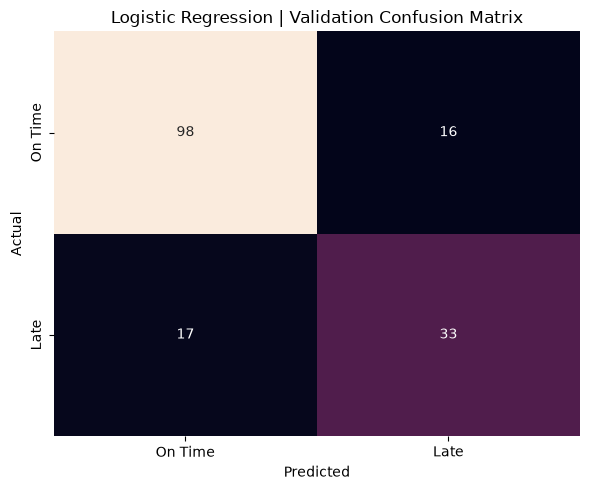

In [94]:
plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    logistic_confusion_matrix,
    annot=True,
    fmt="d",
    cbar=False,
    xticklabels=[
        "On Time",
        "Late"
    ],
    yticklabels=[
        "On Time",
        "Late"
    ]
)

plt.title(
    "Logistic Regression | Validation Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.tight_layout()
plt.show()

### Random Forest

Random Forest is the first nonlinear model in the comparison.

It can capture interactions and nonlinear relationships between order features.

The initial model is evaluated without hyperparameter tuning.

The same validation period and the default threshold of 0.50 are used for a fair comparison.

In [96]:
from sklearn.ensemble import RandomForestClassifier

In [95]:
tree_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

tree_numerical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            tree_categorical_transformer,
            CATEGORICAL_FEATURES
        ),
        (
            "numerical",
            tree_numerical_transformer,
            NUMERICAL_FEATURES
        )
    ]
)

In [97]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=6,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [98]:
random_forest_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['store_id','staff_id','order_month_number',...,'total_units', 'net_order_value','effective_discount_pct']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).B

In [99]:
random_forest_validation_probability = (
    random_forest_model.predict_proba(
        X_validation
    )[:, 1]
)

In [100]:
random_forest_metrics = (
    calculate_classification_metrics(
        y_true=y_validation,
        y_probability=
            random_forest_validation_probability,
        threshold=0.50
    )
)

random_forest_metrics

{'ROC_AUC': 0.8470175438596491,
 'PR_AUC': 0.7034127050412697,
 'Precision': 0.6551724137931034,
 'Recall': 0.38,
 'F1': 0.4810126582278481,
 'F2': 0.4148471615720524,
 'Accuracy': 0.75}

In [101]:
model_comparison = pd.DataFrame(
    [
        {
            "Model": "Dummy Classifier",
            **dummy_metrics
        },
        {
            "Model": "Logistic Regression",
            **logistic_metrics
        },
        {
            "Model": "Random Forest",
            **random_forest_metrics
        }
    ]
).sort_values(
    "PR_AUC",
    ascending=False
)

model_comparison

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,F2,Accuracy
1,Logistic Regression,0.859,0.708,0.673,0.660,0.667,0.663,0.799
2,Random Forest,0.847,0.703,0.655,0.380,0.481,0.415,0.750
0,Dummy Classifier,0.500,0.305,0.000,0.000,0.000,0.000,0.695


### Random Forest Results

Random Forest provides strong ranking performance, but it does not outperform Logistic Regression.

Its validation PR-AUC is close to Logistic Regression:

- Logistic Regression PR-AUC: 0.708
- Random Forest PR-AUC: 0.703

However, at the default threshold of 0.50, Random Forest has much lower recall.

This means that the model identifies fewer late orders at the current threshold.

Because threshold optimization will be performed later, Random Forest will remain in the model comparison.

Logistic Regression is currently the strongest model.

### XGBoost

XGBoost is the next nonlinear classification model.

It can capture complex interactions between order characteristics and late shipment risk.

The initial model will be evaluated without hyperparameter tuning.

The same validation period and classification threshold of 0.50 are used for the initial comparison.

In [102]:
from xgboost import XGBClassifier

In [103]:
xgboost_model = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.03,
                max_depth=3,
                min_child_weight=5,
                subsample=0.9,
                colsample_bytree=0.9,
                reg_alpha=0.1,
                reg_lambda=1.0,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [104]:
xgboost_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['store_id','staff_id','order_month_number',...,'total_units', 'net_order_value','effective_discount_pct']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [105]:
xgboost_validation_probability = (
    xgboost_model.predict_proba(
        X_validation
    )[:, 1]
)

In [106]:
xgboost_metrics = (
    calculate_classification_metrics(
        y_true=y_validation,
        y_probability=
            xgboost_validation_probability,
        threshold=0.50
    )
)

xgboost_metrics

{'ROC_AUC': 0.8449122807017544,
 'PR_AUC': 0.7123314245523915,
 'Precision': 0.6521739130434783,
 'Recall': 0.6,
 'F1': 0.625,
 'F2': 0.6097560975609756,
 'Accuracy': 0.7804878048780488}

In [107]:
model_comparison = pd.DataFrame(
    [
        {
            "Model": "Dummy Classifier",
            **dummy_metrics
        },
        {
            "Model": "Logistic Regression",
            **logistic_metrics
        },
        {
            "Model": "Random Forest",
            **random_forest_metrics
        },
        {
            "Model": "XGBoost",
            **xgboost_metrics
        }
    ]
).sort_values(
    "PR_AUC",
    ascending=False
)

model_comparison

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,F2,Accuracy
3,XGBoost,0.845,0.712,0.652,0.600,0.625,0.610,0.780
1,Logistic Regression,0.859,0.708,0.673,0.660,0.667,0.663,0.799
2,Random Forest,0.847,0.703,0.655,0.380,0.481,0.415,0.750
0,Dummy Classifier,0.500,0.305,0.000,0.000,0.000,0.000,0.695


### XGBoost Results

XGBoost achieves the highest PR-AUC so far.

Its validation results are:

- ROC-AUC: 0.845
- PR-AUC: 0.712
- Precision: 0.652
- Recall: 0.600
- F1 Score: 0.625
- F2 Score: 0.610

XGBoost slightly improves PR-AUC compared with Logistic Regression.

However, Logistic Regression still has better ROC-AUC, recall, F1, and F2 scores.

The difference in PR-AUC is small, so both models remain strong candidates.

### LightGBM

LightGBM is another gradient boosting model.

It can capture nonlinear relationships and interactions between order features.

The initial model will be evaluated without hyperparameter tuning.

The same validation period and threshold of 0.50 are used for a fair comparison.

In [108]:
from lightgbm import LGBMClassifier

In [109]:
lightgbm_model = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "model",
            LGBMClassifier(
                n_estimators=300,
                learning_rate=0.03,
                num_leaves=15,
                max_depth=-1,
                min_child_samples=20,
                subsample=0.9,
                colsample_bytree=0.9,
                reg_alpha=0.1,
                reg_lambda=1.0,
                random_state=42,
                verbosity=-1
            )
        )
    ]
)

In [110]:
lightgbm_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['store_id','staff_id','order_month_number',...,'total_units', 'net_order_value','effective_discount_pct']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).B

In [111]:
lightgbm_validation_probability = (
    lightgbm_model.predict_proba(
        X_validation
    )[:, 1]
)

In [112]:
lightgbm_metrics = (
    calculate_classification_metrics(
        y_true=y_validation,
        y_probability=
            lightgbm_validation_probability,
        threshold=0.50
    )
)

lightgbm_metrics

{'ROC_AUC': 0.8247368421052632,
 'PR_AUC': 0.6679007353796467,
 'Precision': 0.5833333333333334,
 'Recall': 0.56,
 'F1': 0.5714285714285714,
 'F2': 0.5645161290322581,
 'Accuracy': 0.7439024390243902}

In [113]:
model_comparison = pd.DataFrame(
    [
        {
            "Model": "Dummy Classifier",
            **dummy_metrics
        },
        {
            "Model": "Logistic Regression",
            **logistic_metrics
        },
        {
            "Model": "Random Forest",
            **random_forest_metrics
        },
        {
            "Model": "XGBoost",
            **xgboost_metrics
        },
        {
            "Model": "LightGBM",
            **lightgbm_metrics
        }
    ]
).sort_values(
    "PR_AUC",
    ascending=False
)

model_comparison

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,F2,Accuracy
3,XGBoost,0.845,0.712,0.652,0.600,0.625,0.610,0.780
1,Logistic Regression,0.859,0.708,0.673,0.660,0.667,0.663,0.799
2,Random Forest,0.847,0.703,0.655,0.380,0.481,0.415,0.750
4,LightGBM,0.825,0.668,0.583,0.560,0.571,0.565,0.744
0,Dummy Classifier,0.500,0.305,0.000,0.000,0.000,0.000,0.695


### LightGBM Results

LightGBM does not improve validation performance.

Its PR-AUC is 0.668, which is lower than Logistic Regression, Random Forest, and XGBoost.

The model also has lower ROC-AUC, precision, recall, and F1 compared with the strongest candidates.

Therefore, LightGBM will not be prioritized for hyperparameter tuning.

### CatBoost

CatBoost is the final model in the initial model comparison.

Unlike the previous tree models, CatBoost can work directly with categorical features.

This allows the model to learn interactions between store, staff, calendar information, and numerical order features without one-hot encoding.

The initial model is evaluated without hyperparameter tuning.

In [114]:
from catboost import CatBoostClassifier

In [125]:
X_train_cat = X_train.copy()
X_validation_cat = X_validation.copy()

for column in CATEGORICAL_FEATURES:

    X_train_cat[column] = (
        X_train_cat[column]
        .astype(str)
    )

    X_validation_cat[column] = (
        X_validation_cat[column]
        .astype(str)
    )

In [126]:
catboost_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.03,
    depth=5,
    l2_leaf_reg=5,
    loss_function="Logloss",
    eval_metric="PRAUC",
    random_seed=42,
    verbose=False
)

In [127]:
catboost_model.fit(
    X_train_cat,
    y_train,
    cat_features=CATEGORICAL_FEATURES
)

CatBoostClassifier(depth=5, eval_metric='PRAUC', iterations=300, l2_leaf_reg=5, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=False)

In [128]:
catboost_validation_probability = (
    catboost_model.predict_proba(
        X_validation_cat
    )[:, 1]
)

In [129]:
catboost_metrics = (
    calculate_classification_metrics(
        y_true=y_validation,
        y_probability=
            catboost_validation_probability,
        threshold=0.50
    )
)

catboost_metrics

{'ROC_AUC': 0.8466666666666667,
 'PR_AUC': 0.6913460892314222,
 'Precision': 0.6808510638297872,
 'Recall': 0.64,
 'F1': 0.6597938144329897,
 'F2': 0.6477732793522267,
 'Accuracy': 0.7987804878048781}

In [130]:
model_comparison = pd.DataFrame(
    [
        {
            "Model": "Dummy Classifier",
            **dummy_metrics
        },
        {
            "Model": "Logistic Regression",
            **logistic_metrics
        },
        {
            "Model": "Random Forest",
            **random_forest_metrics
        },
        {
            "Model": "XGBoost",
            **xgboost_metrics
        },
        {
            "Model": "LightGBM",
            **lightgbm_metrics
        },
        {
            "Model": "CatBoost",
            **catboost_metrics
        }
    ]
).sort_values(
    "PR_AUC",
    ascending=False
)

model_comparison

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,F2,Accuracy
3,XGBoost,0.845,0.712,0.652,0.600,0.625,0.610,0.780
1,Logistic Regression,0.859,0.708,0.673,0.660,0.667,0.663,0.799
2,Random Forest,0.847,0.703,0.655,0.380,0.481,0.415,0.750
5,CatBoost,0.847,0.691,0.681,0.640,0.660,0.648,0.799
4,LightGBM,0.825,0.668,0.583,0.560,0.571,0.565,0.744
0,Dummy Classifier,0.500,0.305,0.000,0.000,0.000,0.000,0.695


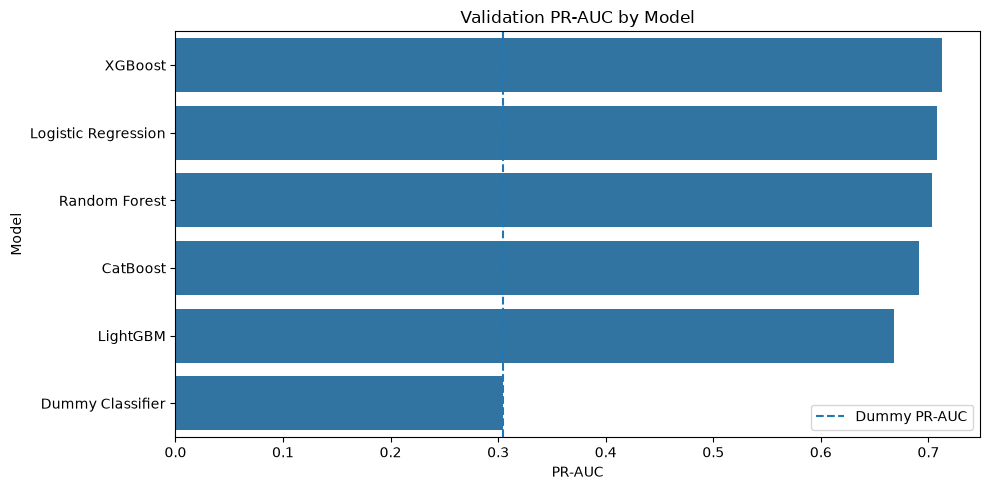

In [131]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=model_comparison,
    x="PR_AUC",
    y="Model"
)

plt.axvline(
    dummy_metrics["PR_AUC"],
    linestyle="--",
    label="Dummy PR-AUC"
)

plt.title(
    "Validation PR-AUC by Model"
)

plt.xlabel("PR-AUC")
plt.ylabel("Model")

plt.legend()

plt.tight_layout()
plt.show()

### Initial Model Comparison

Several classification models were evaluated on the validation period.

XGBoost achieved the highest PR-AUC, while Logistic Regression achieved the highest ROC-AUC, recall, F1, and F2 scores.

The differences between the strongest models are relatively small.

Random Forest also provides competitive ranking performance, but its recall is low at the default threshold.

CatBoost performs well but does not improve PR-AUC compared with XGBoost or Logistic Regression.

LightGBM provides the weakest performance among the main machine learning models.

Because the strongest models are close, a single validation period is not enough for final model selection.

The next step is expanding-window time-based cross-validation.

### Expanding-Window Cross-Validation

The strongest models are close on the validation period.

To evaluate model stability, we use expanding-window cross-validation inside the training period.

Each fold trains on earlier orders and validates on later orders.

The folds are:

- Train through December 2016 → validate January to March 2017
- Train through March 2017 → validate April to June 2017
- Train through June 2017 → validate July to September 2017

The external validation period from October to December 2017 is not used in these folds.

In [132]:
CV_FOLDS = [
    {
        "fold": 1,
        "train_end": pd.Timestamp("2016-12-31"),
        "valid_start": pd.Timestamp("2017-01-01"),
        "valid_end": pd.Timestamp("2017-03-31")
    },
    {
        "fold": 2,
        "train_end": pd.Timestamp("2017-03-31"),
        "valid_start": pd.Timestamp("2017-04-01"),
        "valid_end": pd.Timestamp("2017-06-30")
    },
    {
        "fold": 3,
        "train_end": pd.Timestamp("2017-06-30"),
        "valid_start": pd.Timestamp("2017-07-01"),
        "valid_end": pd.Timestamp("2017-09-30")
    }
]

In [133]:
cv_summary = []

for fold in CV_FOLDS:

    fold_train = orders[
        orders["order_date"]
        <= fold["train_end"]
    ]

    fold_valid = orders[
        orders["order_date"].between(
            fold["valid_start"],
            fold["valid_end"]
        )
    ]

    cv_summary.append({
        "Fold": fold["fold"],
        "Train End":
            fold["train_end"],
        "Train Orders":
            len(fold_train),
        "Train Late Rate":
            fold_train["is_late"].mean() * 100,
        "Validation Start":
            fold["valid_start"],
        "Validation End":
            fold["valid_end"],
        "Validation Orders":
            len(fold_valid),
        "Validation Late Rate":
            fold_valid["is_late"].mean() * 100
    })

cv_summary = pd.DataFrame(
    cv_summary
)

cv_summary

,Fold,Train End,Train Orders,Train Late Rate,Validation Start,Validation End,Validation Orders,Validation Late Rate
0,1,2016-12-31,620,30.806,2017-01-01,2017-03-31,170,42.353
1,2,2017-03-31,790,33.291,2017-04-01,2017-06-30,173,29.480
2,3,2017-06-30,963,32.606,2017-07-01,2017-09-30,164,25.610


### Cross-Validation Fold Check

The validation late shipment rate changes across time.

- Fold 1: 42.4%
- Fold 2: 29.5%
- Fold 3: 25.6%

This makes the cross-validation more challenging and helps test model stability under changing shipment conditions.

PR-AUC is affected by positive-class prevalence.

Therefore, all models will be compared on exactly the same folds, and PR-AUC lift over the validation late rate will also be reported.

In [143]:
def evaluate_time_cv(
    orders,
    folds,
    model_builder,
    features,
    target,
    model_name
):
    """
    Evaluate an sklearn-style classification model
    with expanding-window time-based cross-validation.
    """

    results = []

    for fold in folds:

        fold_train = (
            orders[
                orders["order_date"]
                <= fold["train_end"]
            ]
            .copy()
        )

        fold_valid = (
            orders[
                orders["order_date"]
                .between(
                    fold["valid_start"],
                    fold["valid_end"]
                )
            ]
            .copy()
        )

        X_fold_train = (
            fold_train[features]
            .copy()
        )

        y_fold_train = (
            fold_train[target]
            .copy()
        )

        X_fold_valid = (
            fold_valid[features]
            .copy()
        )

        y_fold_valid = (
            fold_valid[target]
            .copy()
        )

        model = model_builder()

        model.fit(
            X_fold_train,
            y_fold_train
        )

        probability = (
            model.predict_proba(
                X_fold_valid
            )[:, 1]
        )

        validation_late_rate = (
            y_fold_valid.mean()
        )

        pr_auc = average_precision_score(
            y_fold_valid,
            probability
        )

        results.append({
            "Model": model_name,
            "Fold": fold["fold"],
            "Train Orders":
                len(fold_train),
            "Validation Orders":
                len(fold_valid),
            "Validation Late Rate":
                validation_late_rate,
            "PR_AUC":
                pr_auc,
            "PR_AUC_Lift":
                (
                    pr_auc
                    / validation_late_rate
                ),
            "ROC_AUC":
                roc_auc_score(
                    y_fold_valid,
                    probability
                )
        })

    return pd.DataFrame(
        results
    )

In [144]:
from sklearn.base import clone

In [145]:
def build_logistic_model():

    return Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor)
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    random_state=42
                )
            )
        ]
    )

def build_random_forest_model():

    return Pipeline(
        steps=[
            (
                "preprocessor",
                clone(tree_preprocessor)
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    max_depth=6,
                    min_samples_split=10,
                    min_samples_leaf=5,
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )

def build_xgboost_model():

    return Pipeline(
        steps=[
            (
                "preprocessor",
                clone(tree_preprocessor)
            ),
            (
                "model",
                XGBClassifier(
                    n_estimators=300,
                    learning_rate=0.03,
                    max_depth=3,
                    min_child_weight=5,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    reg_alpha=0.1,
                    reg_lambda=1.0,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )

In [146]:
logistic_cv = evaluate_time_cv(
    orders=orders,
    folds=CV_FOLDS,
    model_builder=
        build_logistic_model,
    features=MODEL_FEATURES,
    target=TARGET,
    model_name=
        "Logistic Regression"
)

In [147]:
random_forest_cv = evaluate_time_cv(
    orders=orders,
    folds=CV_FOLDS,
    model_builder=
        build_random_forest_model,
    features=MODEL_FEATURES,
    target=TARGET,
    model_name=
        "Random Forest"
)

In [148]:
xgboost_cv = evaluate_time_cv(
    orders=orders,
    folds=CV_FOLDS,
    model_builder=
        build_xgboost_model,
    features=MODEL_FEATURES,
    target=TARGET,
    model_name=
        "XGBoost"
)

In [149]:
cv_results = pd.concat(
    [
        logistic_cv,
        random_forest_cv,
        xgboost_cv
    ],
    ignore_index=True
)

cv_results

,Model,Fold,Train Orders,Validation Orders,Validation Late Rate,PR_AUC,PR_AUC_Lift,ROC_AUC
0,Logistic Regression,1,620,170,0.424,0.665,1.571,0.806
1,Logistic Regression,2,790,173,0.295,0.644,2.184,0.859
2,Logistic Regression,3,963,164,0.256,0.546,2.134,0.813
3,Random Forest,1,620,170,0.424,0.679,1.603,0.805
4,Random Forest,2,790,173,0.295,0.591,2.005,0.854
5,Random Forest,3,963,164,0.256,0.586,2.289,0.803
6,XGBoost,1,620,170,0.424,0.659,1.556,0.806
7,XGBoost,2,790,173,0.295,0.625,2.119,0.852
8,XGBoost,3,963,164,0.256,0.577,2.252,0.807


In [150]:
cv_model_summary = (
    cv_results.groupby(
        "Model",
        observed=True
    )
    .agg(
        mean_PR_AUC=(
            "PR_AUC",
            "mean"
        ),
        std_PR_AUC=(
            "PR_AUC",
            "std"
        ),
        mean_PR_AUC_Lift=(
            "PR_AUC_Lift",
            "mean"
        ),
        mean_ROC_AUC=(
            "ROC_AUC",
            "mean"
        ),
        std_ROC_AUC=(
            "ROC_AUC",
            "std"
        )
    )
    .reset_index()
    .sort_values(
        "mean_PR_AUC",
        ascending=False
    )
)

cv_model_summary

,Model,mean_PR_AUC,std_PR_AUC,mean_PR_AUC_Lift,mean_ROC_AUC,std_ROC_AUC
2,XGBoost,0.620,0.041,1.976,0.822,0.026
1,Random Forest,0.619,0.052,1.965,0.821,0.029
0,Logistic Regression,0.619,0.063,1.963,0.826,0.029


### Cross-Validation Results

The strongest models have very similar cross-validation performance.

Average PR-AUC:

- XGBoost: 0.620
- Random Forest: 0.619
- Logistic Regression: 0.619

XGBoost has the lowest PR-AUC variability across folds, while Logistic Regression has the highest average ROC-AUC.

The differences are very small.

This shows that no model clearly dominates across all time periods.

CatBoost will also be evaluated using the same expanding-window folds before selecting models for tuning.

In [151]:
def evaluate_catboost_time_cv(
    orders,
    folds,
    features,
    categorical_features,
    target,
    model_params
):
    """
    Evaluate CatBoost with expanding-window
    time-based cross-validation.
    """

    results = []

    for fold in folds:

        fold_train = (
            orders[
                orders["order_date"]
                <= fold["train_end"]
            ]
            .copy()
        )

        fold_valid = (
            orders[
                orders["order_date"]
                .between(
                    fold["valid_start"],
                    fold["valid_end"]
                )
            ]
            .copy()
        )

        X_fold_train = (
            fold_train[features]
            .copy()
        )

        y_fold_train = (
            fold_train[target]
            .copy()
        )

        X_fold_valid = (
            fold_valid[features]
            .copy()
        )

        y_fold_valid = (
            fold_valid[target]
            .copy()
        )

        for column in categorical_features:

            X_fold_train[column] = (
                X_fold_train[column]
                .astype(str)
            )

            X_fold_valid[column] = (
                X_fold_valid[column]
                .astype(str)
            )

        model = CatBoostClassifier(
            **model_params
        )

        model.fit(
            X_fold_train,
            y_fold_train,
            cat_features=
                categorical_features
        )

        probability = (
            model.predict_proba(
                X_fold_valid
            )[:, 1]
        )

        validation_late_rate = (
            y_fold_valid.mean()
        )

        pr_auc = (
            average_precision_score(
                y_fold_valid,
                probability
            )
        )

        results.append({
            "Model": "CatBoost",
            "Fold": fold["fold"],
            "Train Orders":
                len(fold_train),
            "Validation Orders":
                len(fold_valid),
            "Validation Late Rate":
                validation_late_rate,
            "PR_AUC":
                pr_auc,
            "PR_AUC_Lift":
                (
                    pr_auc
                    / validation_late_rate
                ),
            "ROC_AUC":
                roc_auc_score(
                    y_fold_valid,
                    probability
                )
        })

    return pd.DataFrame(
        results
    )

In [152]:
CATBOOST_PARAMS = {
    "iterations": 300,
    "learning_rate": 0.03,
    "depth": 5,
    "l2_leaf_reg": 5,
    "loss_function": "Logloss",
    "random_seed": 42,
    "verbose": False
}

In [153]:
catboost_cv = (
    evaluate_catboost_time_cv(
        orders=orders,
        folds=CV_FOLDS,
        features=MODEL_FEATURES,
        categorical_features=
            CATEGORICAL_FEATURES,
        target=TARGET,
        model_params=
            CATBOOST_PARAMS
    )
)

catboost_cv

,Model,Fold,Train Orders,Validation Orders,Validation Late Rate,PR_AUC,PR_AUC_Lift,ROC_AUC
0,CatBoost,1,620,170,0.424,0.652,1.538,0.790
1,CatBoost,2,790,173,0.295,0.619,2.101,0.864
2,CatBoost,3,963,164,0.256,0.500,1.952,0.781


In [154]:
cv_results_all = pd.concat(
    [
        logistic_cv,
        random_forest_cv,
        xgboost_cv,
        catboost_cv
    ],
    ignore_index=True
)

cv_results_all

,Model,Fold,Train Orders,Validation Orders,Validation Late Rate,PR_AUC,PR_AUC_Lift,ROC_AUC
0,Logistic Regression,1,620,170,0.424,0.665,1.571,0.806
1,Logistic Regression,2,790,173,0.295,0.644,2.184,0.859
2,Logistic Regression,3,963,164,0.256,0.546,2.134,0.813
3,Random Forest,1,620,170,0.424,0.679,1.603,0.805
4,Random Forest,2,790,173,0.295,0.591,2.005,0.854
5,Random Forest,3,963,164,0.256,0.586,2.289,0.803
6,XGBoost,1,620,170,0.424,0.659,1.556,0.806
7,XGBoost,2,790,173,0.295,0.625,2.119,0.852
8,XGBoost,3,963,164,0.256,0.577,2.252,0.807
9,CatBoost,1,620,170,0.424,0.652,1.538,0.790


In [155]:
cv_model_summary = (
    cv_results_all.groupby(
        "Model",
        observed=True
    )
    .agg(
        mean_PR_AUC=(
            "PR_AUC",
            "mean"
        ),
        std_PR_AUC=(
            "PR_AUC",
            "std"
        ),
        mean_PR_AUC_Lift=(
            "PR_AUC_Lift",
            "mean"
        ),
        mean_ROC_AUC=(
            "ROC_AUC",
            "mean"
        ),
        std_ROC_AUC=(
            "ROC_AUC",
            "std"
        )
    )
    .reset_index()
    .sort_values(
        "mean_PR_AUC",
        ascending=False
    )
)

cv_model_summary

,Model,mean_PR_AUC,std_PR_AUC,mean_PR_AUC_Lift,mean_ROC_AUC,std_ROC_AUC
3,XGBoost,0.620,0.041,1.976,0.822,0.026
2,Random Forest,0.619,0.052,1.965,0.821,0.029
1,Logistic Regression,0.619,0.063,1.963,0.826,0.029
0,CatBoost,0.590,0.080,1.864,0.812,0.045


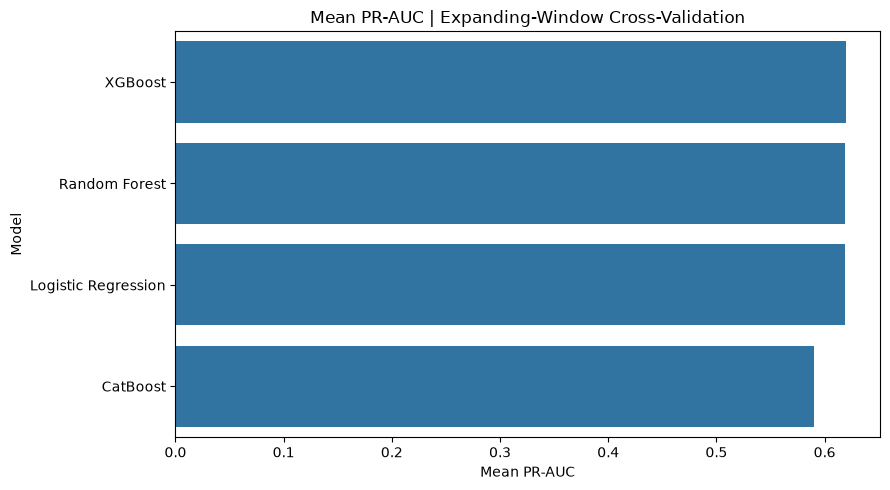

In [156]:
plt.figure(
    figsize=(9, 5)
)

sns.barplot(
    data=cv_model_summary,
    x="mean_PR_AUC",
    y="Model"
)

plt.title(
    "Mean PR-AUC | Expanding-Window Cross-Validation"
)

plt.xlabel(
    "Mean PR-AUC"
)

plt.ylabel(
    "Model"
)

plt.tight_layout()
plt.show()

### Cross-Validation Findings

XGBoost, Random Forest, and Logistic Regression achieve very similar cross-validation performance.

XGBoost has the highest average PR-AUC and the lowest PR-AUC variability.

Logistic Regression has the highest average ROC-AUC.

Random Forest also remains competitive.

CatBoost performs worse and shows higher variability across time periods.

The models selected for hyperparameter tuning are:

- Logistic Regression
- Random Forest
- XGBoost

Hyperparameter tuning will use only the expanding-window cross-validation folds.

The external validation period will not be used for hyperparameter selection.

## 5. Hyperparameter Tuning

The three strongest models will be tuned using the same expanding-window cross-validation folds.

The primary optimization metric is:

**Mean PR-AUC**

Model stability and ROC-AUC will also be considered.

The external validation and test periods are not used during hyperparameter tuning.

In [157]:
from sklearn.model_selection import ParameterGrid

In [158]:
LOGISTIC_PARAM_GRID = {
    "C": [
        0.01,
        0.05,
        0.10,
        0.50,
        1.00,
        2.00,
        5.00,
        10.00
    ],
    "penalty": [
        "l1",
        "l2"
    ],
    "class_weight": [
        None,
        "balanced"
    ]
}

In [159]:
def build_tuned_logistic_model(
    params
):
    """
    Build a Logistic Regression pipeline
    for time-based hyperparameter tuning.
    """

    return Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor)
            ),
            (
                "model",
                LogisticRegression(
                    C=params["C"],
                    penalty=params["penalty"],
                    class_weight=
                        params["class_weight"],
                    solver="liblinear",
                    max_iter=2000,
                    random_state=42
                )
            )
        ]
    )

In [160]:
def tune_model_time_cv(
    orders,
    folds,
    param_grid,
    model_builder,
    features,
    target,
    model_name
):
    """
    Tune a classification model using
    expanding-window time-based cross-validation.
    """

    tuning_results = []

    for config_id, params in enumerate(
        ParameterGrid(param_grid),
        start=1
    ):

        fold_pr_auc = []
        fold_roc_auc = []
        fold_lift = []

        for fold in folds:

            fold_train = (
                orders[
                    orders["order_date"]
                    <= fold["train_end"]
                ]
                .copy()
            )

            fold_valid = (
                orders[
                    orders["order_date"]
                    .between(
                        fold["valid_start"],
                        fold["valid_end"]
                    )
                ]
                .copy()
            )

            X_fold_train = (
                fold_train[features]
                .copy()
            )

            y_fold_train = (
                fold_train[target]
                .copy()
            )

            X_fold_valid = (
                fold_valid[features]
                .copy()
            )

            y_fold_valid = (
                fold_valid[target]
                .copy()
            )

            model = model_builder(
                params
            )

            model.fit(
                X_fold_train,
                y_fold_train
            )

            probability = (
                model.predict_proba(
                    X_fold_valid
                )[:, 1]
            )

            pr_auc = (
                average_precision_score(
                    y_fold_valid,
                    probability
                )
            )

            roc_auc = (
                roc_auc_score(
                    y_fold_valid,
                    probability
                )
            )

            late_rate = (
                y_fold_valid.mean()
            )

            fold_pr_auc.append(
                pr_auc
            )

            fold_roc_auc.append(
                roc_auc
            )

            fold_lift.append(
                pr_auc / late_rate
            )

        tuning_results.append({
            "Model": model_name,
            "Config": config_id,
            **params,
            "mean_PR_AUC":
                np.mean(fold_pr_auc),
            "std_PR_AUC":
                np.std(
                    fold_pr_auc,
                    ddof=1
                ),
            "mean_PR_AUC_Lift":
                np.mean(fold_lift),
            "mean_ROC_AUC":
                np.mean(fold_roc_auc),
            "std_ROC_AUC":
                np.std(
                    fold_roc_auc,
                    ddof=1
                )
        })

    return (
        pd.DataFrame(
            tuning_results
        )
        .sort_values(
            [
                "mean_PR_AUC",
                "mean_ROC_AUC"
            ],
            ascending=[
                False,
                False
            ]
        )
        .reset_index(drop=True)
    )

In [163]:
logistic_tuning_results = (
    tune_model_time_cv(
        orders=orders,
        folds=CV_FOLDS,
        param_grid=
            LOGISTIC_PARAM_GRID,
        model_builder=
            build_tuned_logistic_model,
        features=MODEL_FEATURES,
        target=TARGET,
        model_name=
            "Logistic Regression"
    )
)

In [164]:
logistic_tuning_results.head(10)

,Model,Config,C,class_weight,penalty,mean_PR_AUC,std_PR_AUC,mean_PR_AUC_Lift,mean_ROC_AUC,std_ROC_AUC
0,Logistic Regression,2,0.010,NaN,l2,0.649,0.058,2.060,0.827,0.020
1,Logistic Regression,4,0.010,balanced,l2,0.644,0.056,2.044,0.825,0.028
2,Logistic Regression,6,0.050,NaN,l2,0.633,0.048,2.013,0.826,0.027
3,Logistic Regression,15,0.500,balanced,l1,0.632,0.054,2.009,0.827,0.026
4,Logistic Regression,8,0.050,balanced,l2,0.630,0.052,2.001,0.824,0.032
5,Logistic Regression,13,0.500,NaN,l1,0.627,0.044,1.997,0.824,0.027
6,Logistic Regression,12,0.100,balanced,l2,0.627,0.053,1.993,0.825,0.032
7,Logistic Regression,10,0.100,NaN,l2,0.626,0.048,1.992,0.826,0.029
8,Logistic Regression,19,1.000,balanced,l1,0.624,0.052,1.986,0.827,0.030
9,Logistic Regression,17,1.000,NaN,l1,0.623,0.048,1.981,0.827,0.027


In [165]:
best_logistic_params = (
    logistic_tuning_results
    .iloc[0]
)

best_logistic_params

Model               Logistic Regression
Config                                2
C                                 0.010
class_weight                        NaN
penalty                              l2
mean_PR_AUC                       0.649
std_PR_AUC                        0.058
mean_PR_AUC_Lift                  2.060
mean_ROC_AUC                      0.827
std_ROC_AUC                       0.020
Name: 0, dtype: object

### Logistic Regression Tuning Results

Hyperparameter tuning improved Logistic Regression performance.

The best configuration is:

- C: 0.01
- Penalty: L2
- Class Weight: None

Mean cross-validation PR-AUC increased from 0.619 to 0.649.

The tuned model also maintains stable ROC-AUC performance across time periods.

Stronger regularization appears to improve generalization on this relatively small dataset.

The tuned Logistic Regression will remain a leading candidate for final model selection.

In [166]:
RANDOM_FOREST_PARAM_GRID = {
    "n_estimators": [
        200,
        400
    ],
    "max_depth": [
        4,
        6,
        8,
        None
    ],
    "min_samples_leaf": [
        3,
        5,
        10
    ],
    "max_features": [
        "sqrt",
        0.7
    ],
    "class_weight": [
        None,
        "balanced"
    ]
}

In [167]:
def build_tuned_random_forest_model(
    params
):
    """
    Build a Random Forest pipeline
    for time-based hyperparameter tuning.
    """

    return Pipeline(
        steps=[
            (
                "preprocessor",
                clone(tree_preprocessor)
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=
                        params["n_estimators"],
                    max_depth=
                        params["max_depth"],
                    min_samples_leaf=
                        params["min_samples_leaf"],
                    max_features=
                        params["max_features"],
                    class_weight=
                        params["class_weight"],
                    min_samples_split=10,
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )

In [168]:
random_forest_tuning_results = (
    tune_model_time_cv(
        orders=orders,
        folds=CV_FOLDS,
        param_grid=
            RANDOM_FOREST_PARAM_GRID,
        model_builder=
            build_tuned_random_forest_model,
        features=MODEL_FEATURES,
        target=TARGET,
        model_name=
            "Random Forest"
    )
)

In [169]:
random_forest_tuning_results.head(10)

,Model,Config,class_weight,max_depth,max_features,min_samples_leaf,n_estimators,mean_PR_AUC,std_PR_AUC,mean_PR_AUC_Lift,mean_ROC_AUC,std_ROC_AUC
0,Random Forest,77,balanced,8.000,sqrt,10,200,0.637,0.080,2.009,0.818,0.022
1,Random Forest,47,NaN,NaN,0.700,10,200,0.637,0.022,2.043,0.819,0.033
2,Random Forest,3,NaN,4.000,sqrt,5,200,0.636,0.030,2.035,0.819,0.035
3,Random Forest,35,NaN,8.000,0.700,10,200,0.636,0.016,2.043,0.820,0.032
4,Random Forest,6,NaN,4.000,sqrt,10,400,0.636,0.056,2.019,0.818,0.035
5,Random Forest,1,NaN,4.000,sqrt,3,200,0.636,0.032,2.033,0.817,0.035
6,Random Forest,4,NaN,4.000,sqrt,5,400,0.636,0.035,2.030,0.824,0.030
7,Random Forest,78,balanced,8.000,sqrt,10,400,0.636,0.081,2.004,0.816,0.023
8,Random Forest,12,NaN,4.000,0.700,10,400,0.634,0.011,2.036,0.821,0.029
9,Random Forest,55,balanced,4.000,0.700,3,200,0.634,0.049,2.023,0.821,0.011


In [170]:
best_random_forest_params = (
    random_forest_tuning_results
    .iloc[0]
)

best_random_forest_params

Model               Random Forest
Config                         77
class_weight             balanced
max_depth                   8.000
max_features                 sqrt
min_samples_leaf               10
n_estimators                  200
mean_PR_AUC                 0.637
std_PR_AUC                  0.080
mean_PR_AUC_Lift            2.009
mean_ROC_AUC                0.818
std_ROC_AUC                 0.022
Name: 0, dtype: object

### Random Forest Tuning Results

Hyperparameter tuning improved Random Forest performance.

The best configurations achieve a mean cross-validation PR-AUC of approximately 0.637.

This is higher than the untuned Random Forest result of 0.619, but still lower than the tuned Logistic Regression result of 0.649.

Several Random Forest configurations have very similar average PR-AUC.

Among these configurations, some provide substantially lower variability across time folds.

Therefore, both average performance and temporal stability will be considered during final model selection.

In [171]:
XGBOOST_PARAM_GRID = {
    "n_estimators": [
        200,
        400
    ],
    "learning_rate": [
        0.02,
        0.05
    ],
    "max_depth": [
        2,
        3,
        4
    ],
    "min_child_weight": [
        3,
        8
    ],
    "subsample": [
        0.8,
        1.0
    ],
    "reg_lambda": [
        1.0,
        5.0
    ]
}

In [172]:
def build_tuned_xgboost_model(
    params
):
    """
    Build an XGBoost pipeline
    for time-based hyperparameter tuning.
    """

    return Pipeline(
        steps=[
            (
                "preprocessor",
                clone(tree_preprocessor)
            ),
            (
                "model",
                XGBClassifier(
                    n_estimators=
                        params["n_estimators"],
                    learning_rate=
                        params["learning_rate"],
                    max_depth=
                        params["max_depth"],
                    min_child_weight=
                        params["min_child_weight"],
                    subsample=
                        params["subsample"],
                    reg_lambda=
                        params["reg_lambda"],
                    colsample_bytree=0.9,
                    reg_alpha=0.1,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )

In [173]:
xgboost_tuning_results = (
    tune_model_time_cv(
        orders=orders,
        folds=CV_FOLDS,
        param_grid=
            XGBOOST_PARAM_GRID,
        model_builder=
            build_tuned_xgboost_model,
        features=MODEL_FEATURES,
        target=TARGET,
        model_name="XGBoost"
    )
)

In [174]:
xgboost_tuning_results.head(10)

,Model,Config,learning_rate,max_depth,min_child_weight,n_estimators,reg_lambda,subsample,mean_PR_AUC,std_PR_AUC,mean_PR_AUC_Lift,mean_ROC_AUC,std_ROC_AUC
0,XGBoost,64,0.050,2,8,400,5.000,1.000,0.638,0.036,2.035,0.822,0.030
1,XGBoost,13,0.020,2,8,400,1.000,0.800,0.634,0.042,2.020,0.821,0.026
2,XGBoost,11,0.020,2,8,200,5.000,0.800,0.634,0.047,2.020,0.823,0.034
3,XGBoost,5,0.020,2,3,400,1.000,0.800,0.632,0.053,2.009,0.820,0.022
4,XGBoost,7,0.020,2,3,400,5.000,0.800,0.632,0.054,2.006,0.821,0.027
5,XGBoost,15,0.020,2,8,400,5.000,0.800,0.631,0.039,2.012,0.822,0.026
6,XGBoost,58,0.050,2,8,200,1.000,1.000,0.630,0.034,2.012,0.824,0.032
7,XGBoost,51,0.050,2,3,200,5.000,0.800,0.630,0.058,1.999,0.822,0.025
8,XGBoost,6,0.020,2,3,400,1.000,1.000,0.630,0.069,1.991,0.819,0.026
9,XGBoost,60,0.050,2,8,200,5.000,1.000,0.629,0.033,2.009,0.822,0.033


In [175]:
best_xgboost_params = (
    xgboost_tuning_results
    .iloc[0]
)

best_xgboost_params

Model               XGBoost
Config                   64
learning_rate         0.050
max_depth                 2
min_child_weight          8
n_estimators            400
reg_lambda            5.000
subsample             1.000
mean_PR_AUC           0.638
std_PR_AUC            0.036
mean_PR_AUC_Lift      2.035
mean_ROC_AUC          0.822
std_ROC_AUC           0.030
Name: 0, dtype: object

### XGBoost Tuning Results

Hyperparameter tuning improved XGBoost performance.

The best tuned XGBoost configuration achieved a mean PR-AUC of 0.638, which is higher than the untuned XGBoost result of 0.620.

However, tuned XGBoost still did not outperform the tuned Logistic Regression model, which achieved the best mean PR-AUC of 0.649.

Although XGBoost shows relatively stable performance across time folds, Logistic Regression remains the leading candidate based on the primary evaluation metric.

## 6. Final Validation Comparison

Hyperparameter tuning was performed only with expanding-window cross-validation inside the training period.

The two strongest tuned models are:

- Logistic Regression
- XGBoost

Both models are now trained on the full training period and evaluated on the external validation period.

Model ranking is based primarily on PR-AUC.

Threshold-dependent metrics are also reported using the default threshold of 0.50.

The test period remains untouched.

In [177]:
BEST_LOGISTIC_PARAMS = {
    "C": 0.01,
    "penalty": "l2",
    "class_weight": None
}

BEST_XGBOOST_PARAMS = {
    "n_estimators": 400,
    "learning_rate": 0.05,
    "max_depth": 2,
    "min_child_weight": 8,
    "subsample": 1.0,
    "reg_lambda": 5.0
}

In [178]:
tuned_logistic_model = (
    build_tuned_logistic_model(
        BEST_LOGISTIC_PARAMS
    )
)

tuned_logistic_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['store_id','staff_id','order_month_number',...,'total_units', 'net_order_value','effective_discount_pct']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).B

In [179]:
tuned_logistic_validation_probability = (
    tuned_logistic_model.predict_proba(
        X_validation
    )[:, 1]
)

In [180]:
tuned_logistic_validation_metrics = (
    calculate_classification_metrics(
        y_true=y_validation,
        y_probability=
            tuned_logistic_validation_probability,
        threshold=0.50
    )
)

tuned_logistic_validation_metrics

{'ROC_AUC': 0.8596491228070176,
 'PR_AUC': 0.7190739025025654,
 'Precision': 0.6875,
 'Recall': 0.66,
 'F1': 0.673469387755102,
 'F2': 0.6653225806451613,
 'Accuracy': 0.8048780487804879}

In [181]:
tuned_xgboost_model = (
    build_tuned_xgboost_model(
        BEST_XGBOOST_PARAMS
    )
)

tuned_xgboost_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['store_id','staff_id','order_month_number',...,'total_units', 'net_order_value','effective_discount_pct']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [182]:
tuned_xgboost_validation_probability = (
    tuned_xgboost_model.predict_proba(
        X_validation
    )[:, 1]
)

In [183]:
tuned_xgboost_validation_metrics = (
    calculate_classification_metrics(
        y_true=y_validation,
        y_probability=
            tuned_xgboost_validation_probability,
        threshold=0.50
    )
)

tuned_xgboost_validation_metrics

{'ROC_AUC': 0.8403508771929824,
 'PR_AUC': 0.7004931678394484,
 'Precision': 0.6521739130434783,
 'Recall': 0.6,
 'F1': 0.625,
 'F2': 0.6097560975609756,
 'Accuracy': 0.7804878048780488}

In [184]:
finalist_validation_comparison = (
    pd.DataFrame(
        [
            {
                "Model":
                    "Tuned Logistic Regression",
                **tuned_logistic_validation_metrics
            },
            {
                "Model":
                    "Tuned XGBoost",
                **tuned_xgboost_validation_metrics
            }
        ]
    )
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

finalist_validation_comparison

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,F2,Accuracy
0,Tuned Logistic Regression,0.860,0.719,0.688,0.660,0.673,0.665,0.805
1,Tuned XGBoost,0.840,0.700,0.652,0.600,0.625,0.610,0.780


In [185]:
tuning_impact = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression",
            "Version": "Untuned",
            "PR_AUC": logistic_metrics["PR_AUC"],
            "ROC_AUC": logistic_metrics["ROC_AUC"]
        },
        {
            "Model": "Logistic Regression",
            "Version": "Tuned",
            "PR_AUC":
                tuned_logistic_validation_metrics[
                    "PR_AUC"
                ],
            "ROC_AUC":
                tuned_logistic_validation_metrics[
                    "ROC_AUC"
                ]
        },
        {
            "Model": "XGBoost",
            "Version": "Untuned",
            "PR_AUC": xgboost_metrics["PR_AUC"],
            "ROC_AUC": xgboost_metrics["ROC_AUC"]
        },
        {
            "Model": "XGBoost",
            "Version": "Tuned",
            "PR_AUC":
                tuned_xgboost_validation_metrics[
                    "PR_AUC"
                ],
            "ROC_AUC":
                tuned_xgboost_validation_metrics[
                    "ROC_AUC"
                ]
        }
    ]
)

tuning_impact

,Model,Version,PR_AUC,ROC_AUC
0,Logistic Regression,Untuned,0.708,0.859
1,Logistic Regression,Tuned,0.719,0.860
2,XGBoost,Untuned,0.712,0.845
3,XGBoost,Tuned,0.700,0.840


In [186]:
from sklearn.metrics import (
    precision_recall_curve
)

In [187]:
log_precision, log_recall, _ = (
    precision_recall_curve(
        y_validation,
        tuned_logistic_validation_probability
    )
)

xgb_precision, xgb_recall, _ = (
    precision_recall_curve(
        y_validation,
        tuned_xgboost_validation_probability
    )
)

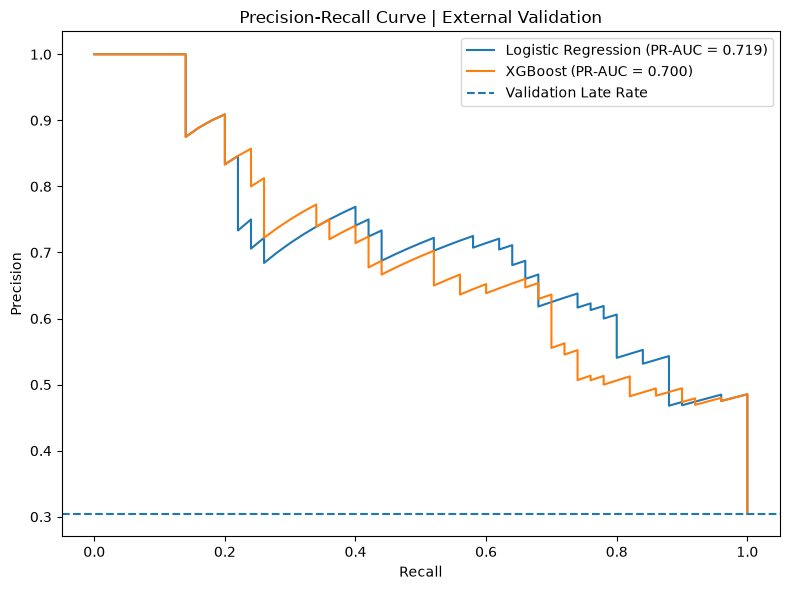

In [188]:
plt.figure(figsize=(8, 6))

plt.plot(
    log_recall,
    log_precision,
    label=(
        "Logistic Regression "
        f"(PR-AUC = "
        f"{tuned_logistic_validation_metrics['PR_AUC']:.3f})"
    )
)

plt.plot(
    xgb_recall,
    xgb_precision,
    label=(
        "XGBoost "
        f"(PR-AUC = "
        f"{tuned_xgboost_validation_metrics['PR_AUC']:.3f})"
    )
)

plt.axhline(
    y_validation.mean(),
    linestyle="--",
    label="Validation Late Rate"
)

plt.title(
    "Precision-Recall Curve | External Validation"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()

plt.tight_layout()
plt.show()

### Finalist Validation Findings

Tuned Logistic Regression provides the strongest external validation performance.

It achieves:

- ROC-AUC: 0.860
- PR-AUC: 0.719
- Precision: 0.688
- Recall: 0.660
- F1 Score: 0.673
- F2 Score: 0.665

Tuned XGBoost performs worse on both PR-AUC and ROC-AUC.

Logistic Regression also improved after tuning, while tuned XGBoost did not improve on the external validation period.

Therefore, Tuned Logistic Regression is selected for threshold optimization.

The test period remains untouched.

## 7. Threshold Optimization

The classification threshold controls the balance between precision and recall.

The default threshold of 0.50 is not necessarily the best operational threshold.

In this problem, missing a truly late order can be more costly than reviewing an order that eventually ships on time.

Therefore, threshold selection will prioritize recall while still considering precision.

F2 Score is used as the main threshold-selection metric because it gives more weight to recall.

Threshold optimization is performed only on the external validation set.

The test set remains untouched.

In [189]:
def evaluate_classification_thresholds(
    y_true,
    y_probability,
    thresholds
):
    """
    Evaluate classification performance
    across probability thresholds.
    """

    results = []

    for threshold in thresholds:

        y_prediction = (
            y_probability >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_prediction
        ).ravel()

        results.append({
            "Threshold": threshold,

            "Precision": precision_score(
                y_true,
                y_prediction,
                zero_division=0
            ),

            "Recall": recall_score(
                y_true,
                y_prediction,
                zero_division=0
            ),

            "F1": f1_score(
                y_true,
                y_prediction,
                zero_division=0
            ),

            "F2": fbeta_score(
                y_true,
                y_prediction,
                beta=2,
                zero_division=0
            ),

            "Accuracy": accuracy_score(
                y_true,
                y_prediction
            ),

            "True_Negatives": tn,
            "False_Positives": fp,
            "False_Negatives": fn,
            "True_Positives": tp
        })

    return pd.DataFrame(results)

In [190]:
thresholds = np.arange(
    0.20,
    0.71,
    0.02
)

In [191]:
threshold_results = (
    evaluate_classification_thresholds(
        y_true=y_validation,
        y_probability=
            tuned_logistic_validation_probability,
        thresholds=thresholds
    )
)

threshold_results

,Threshold,Precision,Recall,F1,F2,Accuracy,True_Negatives,False_Positives,False_Negatives,True_Positives
0,0.200,0.485,1.000,0.654,0.825,0.677,61,53,0,50
1,0.220,0.485,1.000,0.654,0.825,0.677,61,53,0,50
2,0.240,0.485,1.000,0.654,0.825,0.677,61,53,0,50
3,0.260,0.485,1.000,0.654,0.825,0.677,61,53,0,50
4,0.280,0.480,0.940,0.635,0.789,0.671,63,51,3,47
5,0.300,0.506,0.880,0.642,0.767,0.701,71,43,6,44
6,0.320,0.545,0.840,0.661,0.758,0.738,79,35,8,42
7,0.340,0.600,0.780,0.678,0.736,0.774,88,26,11,39
8,0.360,0.613,0.760,0.679,0.725,0.780,90,24,12,38
9,0.380,0.625,0.700,0.660,0.684,0.780,93,21,15,35


In [192]:
best_f2_threshold = (
    threshold_results
    .sort_values(
        [
            "F2",
            "Recall"
        ],
        ascending=[
            False,
            False
        ]
    )
    .iloc[0]
)

best_f2_threshold

Threshold          0.200
Precision          0.485
Recall             1.000
F1                 0.654
F2                 0.825
Accuracy           0.677
True_Negatives    61.000
False_Positives   53.000
False_Negatives    0.000
True_Positives    50.000
Name: 0, dtype: float64

In [193]:
default_threshold_result = (
    threshold_results[
        np.isclose(
            threshold_results["Threshold"],
            0.50
        )
    ]
)

default_threshold_result

,Threshold,Precision,Recall,F1,F2,Accuracy,True_Negatives,False_Positives,False_Negatives,True_Positives
15,0.500,0.688,0.660,0.673,0.665,0.805,99,15,17,33


In [194]:
threshold_comparison = pd.concat(
    [
        default_threshold_result,
        best_f2_threshold
        .to_frame()
        .T
    ],
    ignore_index=True
)

threshold_comparison

,Threshold,Precision,Recall,F1,F2,Accuracy,True_Negatives,False_Positives,False_Negatives,True_Positives
0,0.500,0.688,0.660,0.673,0.665,0.805,99.000,15.000,17.000,33.000
1,0.200,0.485,1.000,0.654,0.825,0.677,61.000,53.000,0.000,50.000


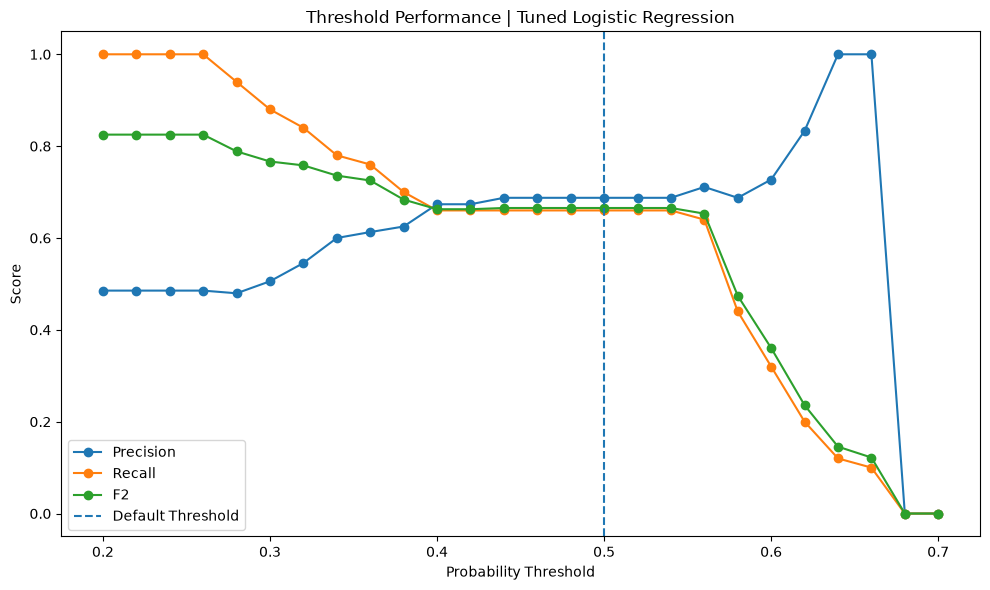

In [195]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F2"],
    marker="o",
    label="F2"
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Default Threshold"
)

plt.title(
    "Threshold Performance | Tuned Logistic Regression"
)

plt.xlabel(
    "Probability Threshold"
)

plt.ylabel(
    "Score"
)

plt.legend()

plt.tight_layout()
plt.show()

In [196]:
selected_thresholds = (
    threshold_results[
        threshold_results["Threshold"]
        .round(2)
        .isin(
            [
                0.30,
                0.35,
                0.40,
                0.45,
                0.50,
                0.55,
                0.60
            ]
        )
    ]
)

selected_thresholds[
    [
        "Threshold",
        "Precision",
        "Recall",
        "F1",
        "F2",
        "False_Positives",
        "False_Negatives",
        "True_Positives"
    ]
]

,Threshold,Precision,Recall,F1,F2,False_Positives,False_Negatives,True_Positives
5,0.300,0.506,0.880,0.642,0.767,43,6,44
10,0.400,0.673,0.660,0.667,0.663,16,17,33
15,0.500,0.688,0.660,0.673,0.665,15,17,33
20,0.600,0.727,0.320,0.444,0.360,6,34,16


In [197]:
FINAL_THRESHOLD = 0.20

### Threshold Selection

The classification threshold has a strong effect on late-shipment detection.

The default threshold of 0.50 identifies 66% of late orders.

Reducing the threshold increases recall.

The highest validation F2 Score is achieved at a threshold of 0.20.

At this threshold:

- Precision: 0.485
- Recall: 1.000
- F2 Score: 0.825
- False Negatives: 0
- False Positives: 53

This threshold prioritizes detecting late orders and accepts more false-positive alerts.

Because F2 was defined before threshold optimization as the primary threshold-selection metric, 0.20 is selected for the final test evaluation.

## 8. Final Test Evaluation

The final model and classification threshold have now been selected.

Final model:

**Tuned Logistic Regression**

Selected threshold:

**0.20**

The test period from January to March 2018 has not been used for model selection, hyperparameter tuning, or threshold optimization.

It is now used once to estimate final out-of-sample performance.

In [198]:
final_train_df = pd.concat(
    [
        train_df,
        validation_df
    ],
    ignore_index=True
)

X_final_train = (
    final_train_df[
        MODEL_FEATURES
    ]
    .copy()
)

y_final_train = (
    final_train_df[
        TARGET
    ]
    .copy()
)

X_final_test = (
    test_df[
        MODEL_FEATURES
    ]
    .copy()
)

y_final_test = (
    test_df[
        TARGET
    ]
    .copy()
)

print(
    "Final train:",
    X_final_train.shape
)

print(
    "Final test:",
    X_final_test.shape
)

Final train: (1291, 9)
Final test: (154, 9)


In [199]:
final_model = (
    build_tuned_logistic_model(
        BEST_LOGISTIC_PARAMS
    )
)

final_model.fit(
    X_final_train,
    y_final_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['store_id','staff_id','order_month_number',...,'total_units', 'net_order_value','effective_discount_pct']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).B

In [200]:
test_probability = (
    final_model.predict_proba(
        X_final_test
    )[:, 1]
)

In [201]:
test_roc_auc = roc_auc_score(
    y_final_test,
    test_probability
)

test_pr_auc = average_precision_score(
    y_final_test,
    test_probability
)

print(
    f"Test ROC-AUC : "
    f"{test_roc_auc:.3f}"
)

print(
    f"Test PR-AUC  : "
    f"{test_pr_auc:.3f}"
)

Test ROC-AUC : 0.800
Test PR-AUC  : 0.559


In [202]:
FINAL_THRESHOLD = 0.20

final_test_metrics = (
    calculate_classification_metrics(
        y_true=y_final_test,
        y_probability=test_probability,
        threshold=FINAL_THRESHOLD
    )
)

final_test_metrics

{'ROC_AUC': 0.7999622926093514,
 'PR_AUC': 0.5588494159280748,
 'Precision': 0.4482758620689655,
 'Recall': 1.0,
 'F1': 0.6190476190476191,
 'F2': 0.8024691358024691,
 'Accuracy': 0.5844155844155844}

In [203]:
final_test_prediction = (
    test_probability
    >= FINAL_THRESHOLD
).astype(int)

final_test_confusion_matrix = (
    confusion_matrix(
        y_final_test,
        final_test_prediction
    )
)

final_test_confusion_matrix

array([[38, 64],
       [ 0, 52]], dtype=int64)

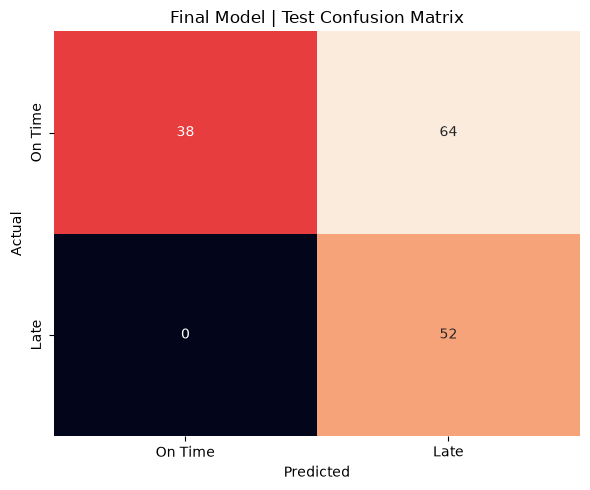

In [204]:
plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    final_test_confusion_matrix,
    annot=True,
    fmt="d",
    cbar=False,
    xticklabels=[
        "On Time",
        "Late"
    ],
    yticklabels=[
        "On Time",
        "Late"
    ]
)

plt.title(
    "Final Model | Test Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [205]:
test_results = test_df[
    [
        "order_id",
        "order_date",
        "store_name",
        "staff_name",
        "required_lead_days",
        "distinct_products",
        "total_units",
        "net_order_value",
        "effective_discount_pct",
        "is_late"
    ]
].copy()

test_results[
    "late_probability"
] = test_probability

test_results[
    "predicted_late"
] = final_test_prediction

test_results[
    "correct_prediction"
] = (
    test_results["is_late"]
    == test_results["predicted_late"]
)

test_results.head()

,order_id,order_date,store_name,staff_name,required_lead_days,distinct_products,total_units,net_order_value,effective_discount_pct,is_late,late_probability,predicted_late,correct_prediction
1291,1324,2018-01-01,Baldwin Bikes,Marcelene Boyer,3,4,5.000,5835.850,18.390,0,0.136,0,True
1292,1325,2018-01-01,Rowlett Bikes,Kali Vargas,1,4,4.000,8729.960,7.130,1,0.629,1,True
1293,1326,2018-01-01,Rowlett Bikes,Layla Terrell,2,2,4.000,5579.960,7.000,0,0.354,1,False
1294,1327,2018-01-02,Baldwin Bikes,Marcelene Boyer,1,4,7.000,7938.930,9.990,1,0.585,1,True
1295,1328,2018-01-02,Baldwin Bikes,Marcelene Boyer,1,5,6.000,3866.040,9.250,0,0.593,1,False


### Final Test Results

The final model maintains useful out-of-sample discrimination on the test period.

Test performance:

- ROC-AUC: 0.800
- PR-AUC: 0.559
- Precision: 0.448
- Recall: 1.000
- F1 Score: 0.619
- F2 Score: 0.802

At the selected threshold of 0.20, the model identifies all 52 late orders in the test period.

However, it also produces 64 false-positive alerts.

This confirms that the selected threshold is designed for high sensitivity rather than high precision.

The ranking metrics are lower than on the validation period, which indicates that the final test period is more difficult.

The model and threshold will not be changed based on test results.

## 9. Error Analysis and Model Interpretation

The final test results show high recall but a relatively large number of false-positive alerts.

We will examine:

- false-positive orders
- correctly identified late orders
- predicted risk distributions
- Logistic Regression coefficients

This helps explain how the model makes risk decisions and where it produces unnecessary alerts.

In [206]:
test_results["error_type"] = np.select(
    [
        (
            (test_results["is_late"] == 1)
            & (test_results["predicted_late"] == 1)
        ),
        (
            (test_results["is_late"] == 0)
            & (test_results["predicted_late"] == 1)
        ),
        (
            (test_results["is_late"] == 1)
            & (test_results["predicted_late"] == 0)
        ),
        (
            (test_results["is_late"] == 0)
            & (test_results["predicted_late"] == 0)
        )
    ],
    [
        "True Positive",
        "False Positive",
        "False Negative",
        "True Negative"
    ]
)

In [207]:
test_results[
    "error_type"
].value_counts()

error_type
False Positive    64
True Positive     52
True Negative     38
Name: count, dtype: int64

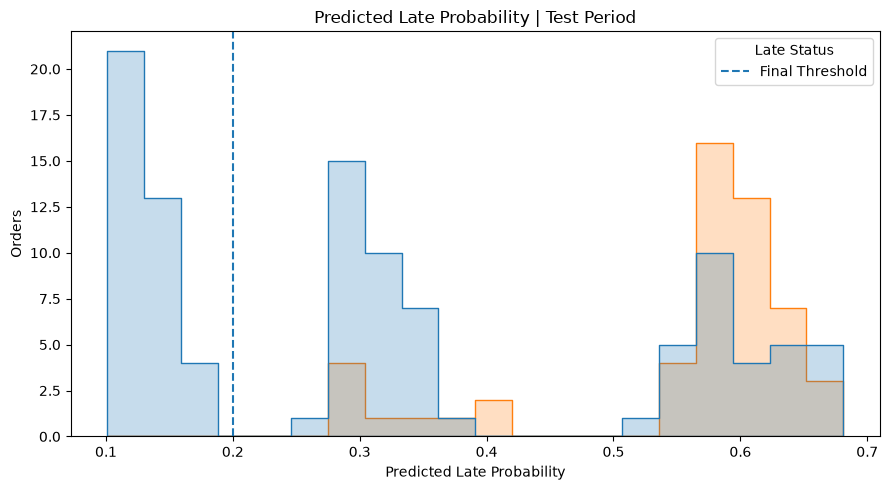

In [208]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=test_results,
    x="late_probability",
    hue="is_late",
    bins=20,
    element="step",
    stat="count",
    common_norm=False
)

plt.axvline(
    FINAL_THRESHOLD,
    linestyle="--",
    label="Final Threshold"
)

plt.title(
    "Predicted Late Probability | Test Period"
)

plt.xlabel(
    "Predicted Late Probability"
)

plt.ylabel(
    "Orders"
)

plt.legend(
    title="Late Status"
)

plt.tight_layout()
plt.show()

In [209]:
false_positive_orders = (
    test_results[
        test_results["error_type"]
        == "False Positive"
    ]
    .sort_values(
        "late_probability",
        ascending=False
    )
)

false_positive_orders.head(15)

,order_id,order_date,store_name,staff_name,required_lead_days,distinct_products,total_units,net_order_value,effective_discount_pct,is_late,late_probability,predicted_late,correct_prediction,error_type
1389,1423,2018-03-06,Santa Cruz Bikes,Mireya Copeland,1,4,5.000,2119.250,18.390,0,0.681,1,False,False Positive
1350,1383,2018-02-07,Santa Cruz Bikes,Genna Serrano,1,2,4.000,6259.260,18.650,0,0.678,1,False,False Positive
1377,1411,2018-03-01,Santa Cruz Bikes,Mireya Copeland,1,2,3.000,3899.970,13.330,0,0.668,1,False,False Positive
1334,1367,2018-01-27,Santa Cruz Bikes,Genna Serrano,1,4,6.000,7947.440,14.520,0,0.665,1,False,False Positive
1307,1340,2018-01-12,Santa Cruz Bikes,Genna Serrano,1,3,5.000,4030.950,14.600,0,0.658,1,False,False Positive
1403,1437,2018-03-15,Santa Cruz Bikes,Mireya Copeland,1,1,2.000,3039.980,5.000,0,0.647,1,False,False Positive
1326,1359,2018-01-21,Rowlett Bikes,Layla Terrell,1,2,2.000,892.980,5.000,0,0.637,1,False,False Positive
1367,1400,2018-02-17,Baldwin Bikes,Marcelene Boyer,1,4,6.000,2738.240,18.500,0,0.637,1,False,False Positive
1313,1346,2018-01-14,Rowlett Bikes,Kali Vargas,1,5,8.000,8797.040,5.690,0,0.634,1,False,False Positive
1300,1333,2018-01-06,Rowlett Bikes,Kali Vargas,1,5,8.000,12369.620,5.990,0,0.624,1,False,False Positive


In [210]:
false_positive_orders[
    [
        "order_id",
        "order_date",
        "store_name",
        "staff_name",
        "required_lead_days",
        "distinct_products",
        "total_units",
        "net_order_value",
        "effective_discount_pct",
        "late_probability"
    ]
].head(15)

,order_id,order_date,store_name,staff_name,required_lead_days,distinct_products,total_units,net_order_value,effective_discount_pct,late_probability
1389,1423,2018-03-06,Santa Cruz Bikes,Mireya Copeland,1,4,5.000,2119.250,18.390,0.681
1350,1383,2018-02-07,Santa Cruz Bikes,Genna Serrano,1,2,4.000,6259.260,18.650,0.678
1377,1411,2018-03-01,Santa Cruz Bikes,Mireya Copeland,1,2,3.000,3899.970,13.330,0.668
1334,1367,2018-01-27,Santa Cruz Bikes,Genna Serrano,1,4,6.000,7947.440,14.520,0.665
1307,1340,2018-01-12,Santa Cruz Bikes,Genna Serrano,1,3,5.000,4030.950,14.600,0.658
1403,1437,2018-03-15,Santa Cruz Bikes,Mireya Copeland,1,1,2.000,3039.980,5.000,0.647
1326,1359,2018-01-21,Rowlett Bikes,Layla Terrell,1,2,2.000,892.980,5.000,0.637
1367,1400,2018-02-17,Baldwin Bikes,Marcelene Boyer,1,4,6.000,2738.240,18.500,0.637
1313,1346,2018-01-14,Rowlett Bikes,Kali Vargas,1,5,8.000,8797.040,5.690,0.634
1300,1333,2018-01-06,Rowlett Bikes,Kali Vargas,1,5,8.000,12369.620,5.990,0.624


In [211]:
error_lead_summary = (
    test_results.groupby(
        [
            "error_type",
            "required_lead_days"
        ],
        observed=True
    )
    .size()
    .reset_index(
        name="orders"
    )
)

error_lead_summary

,error_type,required_lead_days,orders
0,False Positive,1,30
1,False Positive,2,34
2,True Negative,3,38
3,True Positive,1,43
4,True Positive,2,9


In [212]:
final_preprocessor = (
    final_model.named_steps[
        "preprocessor"
    ]
)

final_classifier = (
    final_model.named_steps[
        "model"
    ]
)

feature_names = (
    final_preprocessor
    .get_feature_names_out()
)

coefficients = (
    final_classifier.coef_[0]
)

In [213]:
coefficient_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coefficient_df[
    "abs_coefficient"
] = (
    coefficient_df[
        "coefficient"
    ].abs()
)

coefficient_df = (
    coefficient_df
    .sort_values(
        "abs_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

coefficient_df.head(20)

,feature,coefficient,abs_coefficient
0,numerical__required_lead_days,-0.975,0.975
1,categorical__store_id_2,-0.251,0.251
2,categorical__staff_id_7,-0.155,0.155
3,categorical__order_month_number_9,-0.119,0.119
4,categorical__order_dayofweek_1,-0.111,0.111
5,categorical__store_id_3,-0.111,0.111
6,categorical__order_dayofweek_4,-0.100,0.100
7,categorical__staff_id_6,-0.096,0.096
8,categorical__staff_id_8,-0.076,0.076
9,categorical__order_dayofweek_3,-0.061,0.061


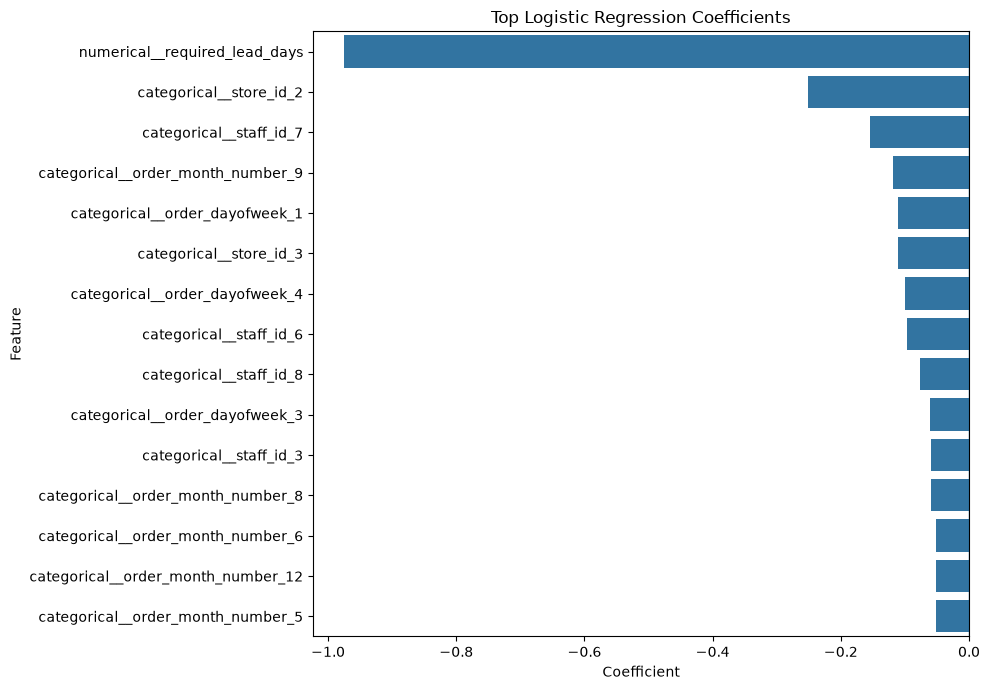

In [214]:
top_coefficients = (
    coefficient_df
    .head(15)
    .sort_values(
        "coefficient"
    )
)

plt.figure(
    figsize=(10, 7)
)

sns.barplot(
    data=top_coefficients,
    x="coefficient",
    y="feature"
)

plt.axvline(
    0,
    linewidth=1
)

plt.title(
    "Top Logistic Regression Coefficients"
)

plt.xlabel(
    "Coefficient"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

### Error Analysis Findings

Required lead time is the dominant risk driver in the final model.

Its Logistic Regression coefficient has the largest absolute magnitude, which confirms the strong relationship observed during exploratory analysis.

In the test period:

- all late orders have a required lead time of 1 or 2 days
- all orders with a 3-day required lead time are correctly classified as on time
- most false-positive alerts also occur among 1-day and 2-day lead-time orders

At the selected threshold of 0.20, the model behaves similarly to a high-sensitivity operational rule based on required lead time.

Other variables such as store, staff, calendar information, order value, and discount provide additional information, but their effects are much smaller.

This means the model is useful as a late-shipment risk ranking system, but its operational alerts are strongly driven by the allowed shipment window.

## Final Model Conclusion

Tuned Logistic Regression is selected as the final model for late shipment risk prediction.

The model was selected using a leakage-safe evaluation process:

1. Orders were split chronologically into train, validation, and test periods.
2. Multiple classification models were compared.
3. Expanding-window cross-validation was used to evaluate temporal stability.
4. Hyperparameters were tuned using only the training period.
5. Final model selection was performed on the external validation period.
6. The classification threshold was selected before evaluating the untouched test period.

### Selected Model

**Tuned Logistic Regression**

Best hyperparameters:

- C: 0.01
- Penalty: L2
- Class Weight: None

### Cross-Validation Performance

The tuned Logistic Regression achieved:

- Mean PR-AUC: 0.649
- Mean ROC-AUC: 0.827

It provided the strongest overall cross-validation performance among the tuned candidate models.

### External Validation Performance

- ROC-AUC: 0.860
- PR-AUC: 0.719
- Precision: 0.688
- Recall: 0.660
- F1 Score: 0.673
- F2 Score: 0.665

The tuned Logistic Regression outperformed the tuned XGBoost model on the external validation period.

### Final Classification Threshold

The final probability threshold was selected using the validation period.

**Threshold: 0.20**

The threshold was selected by maximizing the F2 Score, which gives more importance to recall.

This supports the business objective of identifying potentially late orders before shipment.

### Final Test Performance

On the untouched January-March 2018 test period:

- ROC-AUC: 0.800
- PR-AUC: 0.559
- Precision: 0.448
- Recall: 1.000
- F1 Score: 0.619
- F2 Score: 0.802
- Accuracy: 0.584

The model identified all 52 late orders in the test period.

However, the high-recall threshold also produced 64 false-positive alerts.

Therefore, the final model should be interpreted as an early-warning risk model rather than a strict late/on-time classifier.

### Main Business Finding

Required lead time is the strongest predictor of late shipment risk.

Orders with shorter required lead times have substantially higher late shipment risk.

Other features such as store, staff, calendar information, order size, order value, and discount provide additional information, but their effects are considerably smaller.

### Final Decision

Tuned Logistic Regression is selected because it provides:

- strong time-based cross-validation performance
- the best external validation performance
- good out-of-sample discrimination
- high recall at the selected operating threshold
- simple and interpretable model behavior

The final model can be used as an operational early-warning system to identify orders that may require additional attention before shipment.

In [215]:
final_model_summary = pd.DataFrame(
    [
        {
            "Final Model": "Tuned Logistic Regression",
            "C": 0.01,
            "Penalty": "L2",
            "Class Weight": "None",
            "Threshold": 0.20,
            "Test ROC-AUC": 0.800,
            "Test PR-AUC": 0.559,
            "Test Precision": 0.448,
            "Test Recall": 1.000,
            "Test F1": 0.619,
            "Test F2": 0.802
        }
    ]
)

final_model_summary

,Final Model,C,Penalty,Class Weight,Threshold,Test ROC-AUC,Test PR-AUC,Test Precision,Test Recall,Test F1,Test F2
0,Tuned Logistic Regression,0.010,L2,None,0.200,0.800,0.559,0.448,1.000,0.619,0.802
